In [1]:
!mkdir -p /content/self-healing-detector/src/monitor
!mkdir -p /content/self-healing-detector/src/eval
!mkdir -p /content/self-healing-detector/weights
!mkdir -p /content/self-healing-detector/results/logs

In [2]:
from pathlib import Path

Path("/content/self-healing-detector/weights").mkdir(parents=True, exist_ok=True)


In [3]:
from google.colab import files
uploaded = files.upload()


Saving best_epoch_025.pt to best_epoch_025.pt


In [4]:
from pathlib import Path
import shutil

src = next(iter(uploaded.keys()))  # uploaded filename
dst = Path("/content/self-healing-detector/weights/best.pt")

shutil.move(src, dst)

print(f"Model saved to {dst}")
print(f"Size: {dst.stat().st_size/1024/1024:.2f} MB")

Model saved to /content/self-healing-detector/weights/best.pt
Size: 54.49 MB


In [5]:
from pathlib import Path

root = Path("/content/self-healing-detector")

# Create package directories
dirs = [
    "src",
    "src/model",
    "src/monitor",
    "src/eval",
    "weights",
    "results/logs",
    "results/tables",
    "results/figures",
]

for d in dirs:
    (root / d).mkdir(parents=True, exist_ok=True)

# Make them Python packages
for init in [
    "src/__init__.py",
    "src/model/__init__.py",
    "src/monitor/__init__.py",
    "src/eval/__init__.py",
]:
    (root / init).touch()

print(" Repository package structure recreated.")

 Repository package structure recreated.


In [6]:
%%writefile /content/self-healing-detector/src/model/unfused.py
#!/usr/bin/env python3

import json
from pathlib import Path

import torch
from ultralytics import YOLO
from ultralytics.nn.modules import Conv
from ultralytics.utils.nms import non_max_suppression

BN_KEYS = ("running_mean", "running_var", "num_batches_tracked")


class UnfusedYOLO:

    def __init__(self, weights="weights/best.pt"):

        self.wrapper = YOLO(weights)
        self.net = self.wrapper.model
        self.net.eval()   # Keep BN frozen by default

    def enable_bn_adaptation(self):
        """Enable only BatchNorm statistics updates."""
        self.net.eval()

        for m in self.net.modules():
            if isinstance(m, torch.nn.BatchNorm2d):
                m.train()
                m.momentum = None

    def disable_bn_adaptation(self):
        """Return the entire model to inference mode."""
        self.net.eval()

    def count_bn(self):
        return sum(
            isinstance(m, torch.nn.BatchNorm2d)
            for m in self.net.modules()
        )

    def count_conv(self):
        return sum(
            isinstance(m, Conv)
            for m in self.net.modules()
        )

    def snapshot_bn(self):
        return {
            k: v.detach().clone()
            for k, v in self.net.state_dict().items()
            if any(x in k for x in BN_KEYS)
        }

    def restore_bn(self, backup):

        state = self.net.state_dict()

        for k, v in backup.items():
            state[k] = v.clone()

        self.net.load_state_dict(state)

        self.disable_bn_adaptation()

    @torch.no_grad()
    def forward_raw(self, x):
        return self.net(x)

    @torch.no_grad()
    def infer(self, x, conf=0.001, iou=0.6, nc=6, max_det=100):

        self.disable_bn_adaptation()

        preds = self.forward_raw(x)

        return non_max_suppression(
            preds[0],
            conf_thres=conf,
            iou_thres=iou,
            nc=nc,
            agnostic=False,
            max_det=max_det,
        )


if __name__ == "__main__":

    model = UnfusedYOLO("weights/best.pt")

    out = {
        "bn_layers": model.count_bn(),
        "conv_modules": model.count_conv(),
        "mode": "eval",
    }

    Path("results/logs").mkdir(parents=True, exist_ok=True)

    with open("results/logs/bn_verification.json", "w") as f:
        json.dump(out, f, indent=2)

    print(json.dumps(out, indent=2))

Writing /content/self-healing-detector/src/model/unfused.py


In [7]:
!pip -q install ultralytics imagecorruptions onnx onnxslim openvino

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.0/239.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 10.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.

In [8]:
%cd /content/self-healing-detector
!python src/model/unfused.py

/content/self-healing-detector
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
{
  "bn_layers": 81,
  "conv_modules": 81,
  "mode": "eval"
}


In [9]:
import ultralytics
print("Ultralytics:", ultralytics.__version__)

Ultralytics: 8.4.157


In [10]:
%cd /content/self-healing-detector

from src.model.unfused import UnfusedYOLO

model = UnfusedYOLO("weights/best.pt")

print("BN layers:", model.count_bn())
print("Conv modules:", model.count_conv())

/content/self-healing-detector
BN layers: 81
Conv modules: 81


In [11]:
%%writefile /content/self-healing-detector/src/model/infer.py
#!/usr/bin/env python3

import json
import sys
from pathlib import Path

REPO_ROOT = Path(__file__).resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import cv2
import numpy as np
import torch

from ultralytics.data.augment import LetterBox
from ultralytics.utils.nms import non_max_suppression
from ultralytics.utils.ops import scale_boxes

from src.model.unfused import UnfusedYOLO


class Detector:

    def __init__(self, weights="weights/best.pt", device=None):

        self.model = UnfusedYOLO(weights)
        self.net = self.model.net

        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"

        self.device = device
        self.net.to(device)
        self.net.eval()

        # Default deploy thresholds (we'll tune these later)
        self.thresholds = {
            0: 0.30,  # person
            1: 0.30,  # car
            2: 0.35,  # large_vehicle
            3: 0.45,  # two_wheeler
            4: 0.30,  # traffic_light
            5: 0.30,  # traffic_sign
        }

        self.letterbox = LetterBox(
            new_shape=(768, 768),
            auto=False,
            scale_fill=False,
            scaleup=True,
        )

    def load_thresholds(self, path):
        path = Path(path)
        if path.exists():
            with open(path) as f:
                self.thresholds = {
                    int(k): float(v)
                    for k, v in json.load(f).items()
                }

    def preprocess(self, image):

        img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        img = self.letterbox(image=img)

        tensor = (
            torch.from_numpy(img)
            .permute(2, 0, 1)
            .float()
            .unsqueeze(0)
            / 255.0
        )

        return tensor.to(self.device)

    @torch.no_grad()
    def raw_forward(self, tensor):
        return self.net(tensor)

    @torch.no_grad()
    def infer(self, image, conf=0.001, iou=0.6, max_det=100):

        tensor = self.preprocess(image)

        raw = self.raw_forward(tensor)

        dets = non_max_suppression(
            raw[0],
            conf_thres=conf,
            iou_thres=iou,
            nc=6,
            agnostic=False,
            max_det=max_det,
        )[0]

        if len(dets):
            dets[:, :4] = scale_boxes(
                tensor.shape[2:],
                dets[:, :4],
                image.shape[:2],
            )

        return {
            "raw": raw,
            "detections": dets,
            "tensor": tensor,
        }

    def apply_deploy_thresholds(self, detections):

        if detections is None or len(detections) == 0:
            return detections

        keep = []

        for d in detections:
            cls = int(d[5])

            if float(d[4]) >= self.thresholds.get(cls, 0.30):
                keep.append(d)

        if not keep:
            return torch.empty((0, 6), device=detections.device)

        return torch.stack(keep)


if __name__ == "__main__":

    detector = Detector("weights/best.pt")

    img = np.zeros((720, 1280, 3), dtype=np.uint8)

    out = detector.infer(img)

    print({
        "raw_shape": tuple(out["raw"][0].shape),
        "detections": len(out["detections"]),
        "device": detector.device,
    })

Writing /content/self-healing-detector/src/model/infer.py


In [12]:
%cd /content/self-healing-detector
!python src/model/unfused.py

/content/self-healing-detector
{
  "bn_layers": 81,
  "conv_modules": 81,
  "mode": "eval"
}


In [13]:
%cd /content/self-healing-detector
!python src/model/infer.py

/content/self-healing-detector
{'raw_shape': (1, 10, 12096), 'detections': 0, 'device': 'cuda'}


In [14]:
from ultralytics.data.augment import LetterBox
import inspect
print(inspect.signature(LetterBox))

(new_shape: 'tuple[int, int]' = (640, 640), auto: 'bool' = False, scale_fill: 'bool' = False, scaleup: 'bool' = True, center: 'bool' = True, stride: 'int' = 32, padding_value: 'int' = 114, interpolation: 'int' = 1)


In [105]:
%%writefile /content/self-healing-detector/src/monitor/signals.py
#!/usr/bin/env python3

import argparse
import json
import sys
from pathlib import Path

REPO_ROOT = Path(__file__).resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import cv2
import numpy as np
import pandas as pd
import torch

from src.model.infer import Detector
from src.monitor.flip_consistency import consistency as flip_consistency_fn


def entropy(scores):
    scores = np.asarray(scores, dtype=np.float32)

    if scores.sum() <= 0:
        return 0.0

    scores = np.clip(scores, 1e-9, 1.0)
    scores = scores / scores.sum()

    return float(-np.sum(scores * np.log(scores)))


def brightness_stats(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    v = hsv[:, :, 2].astype(np.float32)

    return (
        float(v.mean()),
        float(v.std()),
        float((v < 40).mean()),
    )


def bn_distance(detector, source_stats):
    total = 0.0
    layers = 0

    for name, module in detector.net.named_modules():

        if (
            isinstance(module, torch.nn.BatchNorm2d)
            and name in source_stats
        ):

            src = source_stats[name]

            total += (
                torch.norm(
                    module.running_mean.cpu() - src["running_mean"]
                ).item()
                +
                torch.norm(
                    module.running_var.cpu() - src["running_var"]
                ).item()
            )

            layers += 1

    return total / max(1, layers)


@torch.no_grad()
def extract_one(detector, image_path, source_stats):

    img = cv2.imread(str(image_path))

    if img is None:
        return None

    out = detector.infer(img, conf=0.001)

    raw = out["raw"][0]
    dets = detector.apply_deploy_thresholds(out["detections"])

    # Convert (1,6,N) -> (N,6)
    probs = raw[:, 4:, :].permute(0, 2, 1).reshape(-1, 6)
    obj_mean = float(probs.max(dim=1).values.mean().cpu())

    confs = []
    ents = []
    small = 0

    if len(dets):

        for d in dets.cpu():

            conf = float(d[4])
            cls = int(d[5])

            confs.append(conf)

            onehot = np.zeros(6, dtype=np.float32)
            onehot[cls] = conf

            ents.append(entropy(onehot))

            x1, y1, x2, y2 = d[:4]

            if (x2 - x1) * (y2 - y1) < 32 * 32:
                small += 1

    v_mean, v_std, dark_frac = brightness_stats(img)

    return {
        "image": image_path.name,
        "conf_mean": float(np.mean(confs)) if confs else 0.0,
        "conf_max": float(np.max(confs)) if confs else 0.0,
        "n_det": int(len(confs)),
        "conf_entropy": float(np.mean(ents)) if ents else 0.0,
        "obj_mean": obj_mean,
        "small_frac": small / max(1, len(confs)),
        "v_mean": v_mean,
        "v_std": v_std,
        "dark_frac": dark_frac,
        "flip_consistency": float(
            flip_consistency_fn(detector, img)
        ),
        "bn_dist": float(
            bn_distance(detector, source_stats)
        ),
    }


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument("--weights", default="weights/best.pt")
    parser.add_argument("--images", required=True)
    parser.add_argument(
        "--bn_source",
        default="weights/bn_source_stats.pt",
    )
    parser.add_argument("--output", default="results/logs")

    args = parser.parse_args()

    detector = Detector(args.weights)

    source_stats = torch.load(
        args.bn_source,
        map_location="cpu",
    )

    img_dir = Path(args.images)

    images = sorted(
        list(img_dir.glob("*.jpg")) +
        list(img_dir.glob("*.png"))
    )

    out_dir = Path(args.output)
    out_dir.mkdir(parents=True, exist_ok=True)

    if not images:

        with open(out_dir / "signals_summary.json", "w") as f:
            json.dump(
                {
                    "images": 0,
                    "status": "no_images_found",
                    "image_dir": str(img_dir),
                },
                f,
                indent=2,
            )

        print(f"No images found in {img_dir}")
        return

    rows = []

    for p in images:

        r = extract_one(
            detector,
            p,
            source_stats,
        )

        if r is not None:
            rows.append(r)

    df = pd.DataFrame(rows)

    df.to_csv(
        out_dir / "signals.csv",
        index=False,
    )

    summary = {
        "images": len(df),
        "mean_conf": float(df.conf_mean.mean()),
        "mean_det": float(df.n_det.mean()),
        "mean_dark_frac": float(df.dark_frac.mean()),
        "mean_flip": float(df.flip_consistency.mean()),
        "mean_bn_dist": float(df.bn_dist.mean()),
    }

    with open(out_dir / "signals_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    print(df.head())
    print(summary)


if __name__ == "__main__":
    main()

Overwriting /content/self-healing-detector/src/monitor/signals.py


In [16]:
!find /content/self-healing-detector/data -maxdepth 3 -type d 2>/dev/null

In [17]:
!python src/monitor/signals.py \
  --weights weights/best.pt \
  --images data/yolo/val_day/images \
  --output results/logs

No images found in data/yolo/val_day/images


In [18]:
!find /content/self-healing-detector/data -maxdepth 3 -type d 2>/dev/null

In [19]:
!mkdir -p /content/self-healing-detector/data/raw
!mkdir -p /content/self-healing-detector/data/yolo/val_day/images

In [20]:
%cd /content/self-healing-detector/data/raw

!kaggle datasets download -d soumikrakshit/bdd100k \
  -f bdd100k_images_10k.zip

!kaggle datasets download -d soumikrakshit/bdd100k \
  -f bdd100k_det_20_labels_trainval.zip

/content/self-healing-detector/data/raw
Dataset URL: https://www.kaggle.com/datasets/soumikrakshit/bdd100k
License(s): unknown
404 Client Error: Not Found for url: https://api.kaggle.com/v1/datasets.DatasetApiService/DownloadDataset
Dataset URL: https://www.kaggle.com/datasets/soumikrakshit/bdd100k
License(s): unknown
404 Client Error: Not Found for url: https://api.kaggle.com/v1/datasets.DatasetApiService/DownloadDataset


In [22]:
%cd /content/self-healing-detector/data/raw

!kaggle datasets download -d soumikrakshit/bdd100k -p .

/content/self-healing-detector/data/raw
Dataset URL: https://www.kaggle.com/datasets/soumikrakshit/bdd100k
License(s): unknown
100% 6.37G/6.37G [03:28<00:00, 32.8MB/s]



In [23]:
%cd /content/self-healing-detector/data/raw

!unzip -q bdd100k.zip
!rm bdd100k.zip

/content/self-healing-detector/data/raw


In [24]:
!mkdir -p /content/self-healing-detector/data/raw/bdd100k/images
!mkdir -p /content/self-healing-detector/data/raw/bdd100k/labels

!mv /content/self-healing-detector/data/raw/bdd100k_images_100k/bdd100k/images/100k/train \
    /content/self-healing-detector/data/raw/bdd100k/images/

!mv /content/self-healing-detector/data/raw/bdd100k_images_100k/bdd100k/images/100k/val \
    /content/self-healing-detector/data/raw/bdd100k/images/

!mv /content/self-healing-detector/data/raw/bdd100k_images_100k/bdd100k/images/100k/test \
    /content/self-healing-detector/data/raw/bdd100k/images/

!cp /content/self-healing-detector/data/raw/bdd100k_det_20_labels_trainval/bdd100k/labels/det_20/det_train.json \
    /content/self-healing-detector/data/raw/bdd100k/labels/

!cp /content/self-healing-detector/data/raw/bdd100k_det_20_labels_trainval/bdd100k/labels/det_20/det_val.json \
    /content/self-healing-detector/data/raw/bdd100k/labels/

!rm -rf /content/self-healing-detector/data/raw/bdd100k_images_100k
!rm -rf /content/self-healing-detector/data/raw/bdd100k_images_10k
!rm -rf /content/self-healing-detector/data/raw/bdd100k_det_20_labels_trainval

In [25]:
!find /content/self-healing-detector/data/raw/bdd100k -maxdepth 2 -type d

/content/self-healing-detector/data/raw/bdd100k
/content/self-healing-detector/data/raw/bdd100k/images
/content/self-healing-detector/data/raw/bdd100k/images/train
/content/self-healing-detector/data/raw/bdd100k/images/val
/content/self-healing-detector/data/raw/bdd100k/images/test
/content/self-healing-detector/data/raw/bdd100k/labels


In [26]:
%cd /content/self-healing-detector

!python scripts/01_prepare_bdd.py \
    --root /content/self-healing-detector

/content/self-healing-detector
python3: can't open file '/content/self-healing-detector/scripts/01_prepare_bdd.py': [Errno 2] No such file or directory


In [27]:
from pathlib import Path

Path("/content/self-healing-detector/scripts").mkdir(parents=True, exist_ok=True)
print(" scripts/ folder ready.")

 scripts/ folder ready.


In [28]:

%%writefile /content/self-healing-detector/scripts/01_prepare_bdd.py
#!/usr/bin/env python3

import argparse
import json
import os
import random
from pathlib import Path

import pandas as pd

IMAGE_W = 1280
IMAGE_H = 720
SEED = 0
random.seed(SEED)

CLASS_MAP = {
    "pedestrian": 0,
    "rider": 0,
    "car": 1,
    "truck": 2,
    "bus": 2,
    "motorcycle": 3,
    "bicycle": 3,
    "traffic light": 4,
    "traffic sign": 5,
}


def clip(v):
    return max(0.0, min(1.0, v))


def convert_box(box, cls):
    x1, y1, x2, y2 = box
    w = x2 - x1
    h = y2 - y1
    if w < 2 or h < 2:
        return None

    cx = (x1 + x2) / 2 / IMAGE_W
    cy = (y1 + y2) / 2 / IMAGE_H

    return (
        f"{cls} "
        f"{clip(cx):.6f} "
        f"{clip(cy):.6f} "
        f"{clip(w/IMAGE_W):.6f} "
        f"{clip(h/IMAGE_H):.6f}"
    )


def parse_json(json_path, image_root):
    with open(json_path) as f:
        data = json.load(f)

    records = []

    for item in data:
        attrs = item["attributes"]
        labels = []

        for obj in item.get("labels", []):
            cat = obj["category"]
            if cat not in CLASS_MAP:
                continue

            b = obj["box2d"]
            line = convert_box(
                (b["x1"], b["y1"], b["x2"], b["y2"]),
                CLASS_MAP[cat],
            )

            if line is not None:
                labels.append(line)

        records.append(
            {
                "image": item["name"],
                "path": image_root / item["name"],
                "timeofday": attrs.get("timeofday"),
                "weather": attrs.get("weather"),
                "scene": attrs.get("scene"),
                "labels": labels,
                "n_objects": len(labels),
            }
        )

    return records


def val_split(r):
    if r["timeofday"] == "night":
        return "val_night"
    if r["weather"] == "rainy":
        return "val_rain"
    if r["timeofday"] in ("dawn", "dusk", "dawn/dusk"):
        return "val_dusk"
    return "val_day"


def make_symlink(src, dst):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() or dst.is_symlink():
        dst.unlink()
    os.symlink(src, dst)


def write_split(records, split, root):
    img_dir = root / "data" / "yolo" / split / "images"
    lbl_dir = root / "data" / "yolo" / split / "labels"

    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    manifest = []

    for r in records:
        dst_img = img_dir / r["image"]
        make_symlink(r["path"].resolve(), dst_img)

        (lbl_dir / f"{Path(r['image']).stem}.txt").write_text(
            "\n".join(r["labels"])
        )

        manifest.append(str(dst_img))

    man_dir = root / "data" / "manifests"
    man_dir.mkdir(parents=True, exist_ok=True)
    (man_dir / f"{split}.txt").write_text("\n".join(manifest))


def main():

    ap = argparse.ArgumentParser()
    ap.add_argument("--root", required=True)
    args = ap.parse_args()

    root = Path(args.root)

    train = parse_json(
        root / "data" / "raw" / "bdd100k" / "labels" / "det_train.json",
        root / "data" / "raw" / "bdd100k" / "images" / "train",
    )

    val = parse_json(
        root / "data" / "raw" / "bdd100k" / "labels" / "det_val.json",
        root / "data" / "raw" / "bdd100k" / "images" / "val",
    )

    train_day = [
        r for r in train
        if r["timeofday"] == "daytime" and r["n_objects"] > 0
    ]

    random.shuffle(train_day)
    train_day = train_day[:18000]

    splits = {
        "val_day": [],
        "val_night": [],
        "val_rain": [],
        "val_dusk": [],
    }

    for r in val:
        splits[val_split(r)].append(r)

    write_split(train_day, "train_day", root)

    for s, recs in splits.items():
        write_split(recs, s, root)

    meta = []

    for s, recs in [("train_day", train_day)] + list(splits.items()):
        for r in recs:
            meta.append(
                {
                    "split": s,
                    "image": r["image"],
                    "timeofday": r["timeofday"],
                    "weather": r["weather"],
                    "scene": r["scene"],
                    "n_objects": r["n_objects"],
                }
            )

    (root / "results" / "logs").mkdir(parents=True, exist_ok=True)
    (root / "results" / "tables").mkdir(parents=True, exist_ok=True)

    pd.DataFrame(meta).to_csv(
        root / "data" / "manifests" / "metadata.csv",
        index=False,
    )

    summary = {
        "seed": SEED,
        "train_day": len(train_day),
        "val_day": len(splits["val_day"]),
        "val_night": len(splits["val_night"]),
        "val_rain": len(splits["val_rain"]),
        "val_dusk": len(splits["val_dusk"]),
    }

    with open(root / "results" / "logs" / "prepare_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    pd.DataFrame(
        [{"split": k, "images": v} for k, v in summary.items() if k != "seed"]
    ).to_csv(
        root / "results" / "tables" / "prepare_summary.csv",
        index=False,
    )

    print(summary)


if __name__ == "__main__":
    main()

Writing /content/self-healing-detector/scripts/01_prepare_bdd.py


In [29]:
%cd /content/self-healing-detector

!python scripts/01_prepare_bdd.py \
    --root /content/self-healing-detector

/content/self-healing-detector
{'seed': 0, 'train_day': 18000, 'val_day': 4896, 'val_night': 3929, 'val_rain': 452, 'val_dusk': 723}


In [30]:
!find /content/self-healing-detector/data/yolo -maxdepth 2 -type d

/content/self-healing-detector/data/yolo
/content/self-healing-detector/data/yolo/val_day
/content/self-healing-detector/data/yolo/val_day/images
/content/self-healing-detector/data/yolo/val_day/labels
/content/self-healing-detector/data/yolo/val_dusk
/content/self-healing-detector/data/yolo/val_dusk/images
/content/self-healing-detector/data/yolo/val_dusk/labels
/content/self-healing-detector/data/yolo/val_night
/content/self-healing-detector/data/yolo/val_night/images
/content/self-healing-detector/data/yolo/val_night/labels
/content/self-healing-detector/data/yolo/val_rain
/content/self-healing-detector/data/yolo/val_rain/images
/content/self-healing-detector/data/yolo/val_rain/labels
/content/self-healing-detector/data/yolo/train_day
/content/self-healing-detector/data/yolo/train_day/images
/content/self-healing-detector/data/yolo/train_day/labels


In [31]:
from pathlib import Path

Path("/content/self-healing-detector/src/monitor").mkdir(parents=True, exist_ok=True)
(Path("/content/self-healing-detector/src/monitor/__init__.py")).touch()

In [103]:
%%writefile /content/self-healing-detector/src/monitor/bn_stats.py
#!/usr/bin/env python3

import argparse
import json
import sys
from pathlib import Path

REPO_ROOT = Path(__file__).resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import cv2
import torch

from src.model.infer import Detector


def collect_bn(model):

    stats = {}

    for name, module in model.net.named_modules():
        if isinstance(module, torch.nn.BatchNorm2d):
            stats[name] = {
                "running_mean": module.running_mean.detach().cpu().clone(),
                "running_var": module.running_var.detach().cpu().clone(),
                "num_batches_tracked": module.num_batches_tracked.detach().cpu().clone(),
            }

    return stats


@torch.no_grad()
def update_bn(detector, image_path):

    img = cv2.imread(str(image_path))

    if img is None:
        return False

    tensor = detector.preprocess(img)
    detector.raw_forward(tensor)

    return True


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument("--weights", default="weights/best.pt")
    parser.add_argument("--images", required=True)
    parser.add_argument("--output", default="weights/bn_source_stats.pt")

    args = parser.parse_args()

    detector = Detector(args.weights)

    img_dir = Path(args.images)

    images = sorted(
        list(img_dir.glob("*.jpg")) +
        list(img_dir.glob("*.png"))
    )

    if not images:
        raise RuntimeError(f"No images found in {img_dir}")

    print(f"Building BN source stats from {len(images)} images...")

    # Enable BN running-stat updates
    detector.model.enable_bn_adaptation()

    processed = 0

    for i, p in enumerate(images, 1):

        if update_bn(detector, p):
            processed += 1

        if i % 500 == 0:
            print(f"{i}/{len(images)}")

    # Return model to normal inference mode
    detector.model.disable_bn_adaptation()

    stats = collect_bn(detector)

    out_path = Path(args.output)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    torch.save(stats, out_path)

    log_dir = REPO_ROOT / "results" / "logs"
    log_dir.mkdir(parents=True, exist_ok=True)

    summary = {
        "bn_layers": len(stats),
        "images_processed": processed,
        "output": str(out_path),
    }

    with open(log_dir / "bn_source_stats.json", "w") as f:
        json.dump(summary, f, indent=2)

    print(summary)


if __name__ == "__main__":
    main()

Overwriting /content/self-healing-detector/src/monitor/bn_stats.py


In [33]:
%cd /content/self-healing-detector

!python src/monitor/bn_stats.py \
  --weights weights/best.pt \
  --images data/yolo/val_day/images \
  --output weights/bn_source_stats.pt

/content/self-healing-detector
Building BN source stats from 4896 images...
500/4896
1000/4896
1500/4896
2000/4896
2500/4896
3000/4896
3500/4896
4000/4896
4500/4896
{'bn_layers': 81, 'images_processed': 4896, 'output': 'weights/bn_source_stats.pt'}


In [104]:
%%writefile /content/self-healing-detector/src/monitor/flip_consistency.py
#!/usr/bin/env python3

import argparse
import json
import sys
from pathlib import Path

REPO_ROOT = Path(__file__).resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import cv2
import numpy as np
import pandas as pd
import torch

from src.model.infer import Detector


def box_iou(a, b):
    a = [float(x) for x in a]
    b = [float(x) for x in b]

    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])

    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)

    if inter <= 0:
        return 0.0

    area1 = max(0.0, a[2] - a[0]) * max(0.0, a[3] - a[1])
    area2 = max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])

    return inter / (area1 + area2 - inter + 1e-9)


def unflip_boxes(dets, width):
    if dets is None or len(dets) == 0:
        return dets

    d = dets.clone()

    x1 = d[:, 0].clone()
    x2 = d[:, 2].clone()

    d[:, 0] = width - x2
    d[:, 2] = width - x1

    return d


@torch.no_grad()
def consistency(detector, image):

    if image is None:
        return np.nan

    normal = detector.apply_deploy_thresholds(
        detector.infer(image, conf=0.001)["detections"]
    )

    flipped_img = cv2.flip(image, 1)

    flipped = detector.apply_deploy_thresholds(
        detector.infer(flipped_img, conf=0.001)["detections"]
    )

    # IMPORTANT: mirror using the ORIGINAL image width
    flipped = unflip_boxes(flipped, width=image.shape[1])

    if len(normal) == 0 and len(flipped) == 0:
        return 1.0

    if len(normal) == 0 or len(flipped) == 0:
        return 0.0

    matches = 0
    used = set()

    normal_cpu = normal.cpu()
    flipped_cpu = flipped.cpu()

    for n in normal_cpu:

        best_iou = 0.0
        best_idx = None

        for j, f in enumerate(flipped_cpu):

            if j in used:
                continue

            if int(n[5]) != int(f[5]):
                continue

            iou = box_iou(n[:4], f[:4])

            if iou > best_iou:
                best_iou = iou
                best_idx = j

        if best_iou >= 0.5:
            matches += 1
            used.add(best_idx)

    return matches / max(len(normal_cpu), len(flipped_cpu))


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument("--weights", default="weights/best.pt")
    parser.add_argument("--images", required=True)
    parser.add_argument("--output", default="results/logs")

    args = parser.parse_args()

    detector = Detector(args.weights)

    img_dir = Path(args.images)
    images = sorted(list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")))

    out_dir = Path(args.output)
    out_dir.mkdir(parents=True, exist_ok=True)

    rows = []

    for i, p in enumerate(images, 1):

        img = cv2.imread(str(p))

        if img is None:
            print(f"Skipping unreadable image: {p}")
            continue

        rows.append({
            "image": p.name,
            "flip_consistency": consistency(detector, img),
        })

        if i % 500 == 0:
            print(f"{i}/{len(images)}")

    df = pd.DataFrame(rows)

    df.to_csv(out_dir / "flip_consistency.csv", index=False)

    summary = {
        "images": len(df),
        "mean_flip_consistency": float(df["flip_consistency"].mean()) if len(df) else None,
    }

    with open(out_dir / "flip_consistency_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    print(summary)


if __name__ == "__main__":
    main()

Overwriting /content/self-healing-detector/src/monitor/flip_consistency.py


In [35]:
%cd /content/self-healing-detector

!rm -rf sample_images
!mkdir sample_images

!find "$(realpath data/yolo/val_day/images)" -name "*.jpg" | head -20 | while read f; do cp "$f" sample_images/; done

!python src/monitor/flip_consistency.py \
  --weights weights/best.pt \
  --images sample_images \
  --output results/logs

/content/self-healing-detector
{'images': 20, 'mean_flip_consistency': 0.005357142857142857}


In [106]:
%%writefile /content/self-healing-detector/src/monitor/predictor.py
#!/usr/bin/env python3

import argparse
import json
import sys
from pathlib import Path

REPO_ROOT = Path(__file__).resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import joblib
import pandas as pd

from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


FEATURES = [
    "conf_mean",
    "conf_max",
    "n_det",
    "conf_entropy",
    "obj_mean",
    "small_frac",
    "v_mean",
    "v_std",
    "dark_frac",
    "flip_consistency",
    "bn_dist",
]


def build_pseudo_labels(df):

    labels = (
        (df["conf_mean"] < 0.35)
        | (df["n_det"] == 0)
        | (df["dark_frac"] > 0.55)
    ).astype(int)

    if labels.nunique() < 2:

        score = (
            -df["conf_mean"]
            + 0.5 * df["dark_frac"]
            - 0.02 * df["n_det"]
        )

        labels = (score >= score.median()).astype(int)

    return labels


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--signals",
        default="results/logs/signals.csv",
    )

    parser.add_argument(
        "--flip",
        default="results/logs/flip_consistency.csv",
    )

    parser.add_argument(
        "--output",
        default="results/models",
    )

    args = parser.parse_args()

    df = pd.read_csv(args.signals)

    flip_path = Path(args.flip)

    if flip_path.exists():

        flip_df = pd.read_csv(flip_path)

        df = df.merge(
            flip_df,
            on="image",
            how="left",
            suffixes=("", "_new"),
        )

        if "flip_consistency_new" in df.columns:
            df["flip_consistency"] = df["flip_consistency_new"]
            df.drop(columns=["flip_consistency_new"], inplace=True)

    # Clean missing values without future pandas warnings
    df["bn_dist"] = (
        df["bn_dist"]
        .fillna(0.0)
        .infer_objects(copy=False)
    )

    df["flip_consistency"] = (
        df["flip_consistency"]
        .fillna(1.0)
        .infer_objects(copy=False)
    )

    df["failure"] = build_pseudo_labels(df)

    X = df[FEATURES].copy()
    y = df["failure"]

    stratify = y if y.nunique() > 1 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=0,
        stratify=stratify,
    )

    scaler = StandardScaler()

    # Keep DataFrames so feature names remain attached
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=FEATURES,
        index=X_train.index,
    )

    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=FEATURES,
        index=X_test.index,
    )

    base = LogisticRegression(
        max_iter=1000,
        random_state=0,
    )

    n_folds = 2 if len(y_train) < 50 else 3

    model = CalibratedClassifierCV(
        estimator=base,
        method="sigmoid",
        cv=n_folds,
    )

    model.fit(X_train_scaled, y_train)

    probs = model.predict_proba(X_test_scaled)[:, 1]
    preds = (probs >= 0.5).astype(int)

    metrics = {
        "accuracy": float(accuracy_score(y_test, preds)),
        "roc_auc": float(roc_auc_score(y_test, probs)),
        "samples": int(len(df)),
        "calibration_folds": n_folds,
        "features": FEATURES,
    }

    out_dir = Path(args.output)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Save scaler together with feature order
    joblib.dump(model, out_dir / "failure_predictor.joblib")

    joblib.dump(
        {
            "scaler": scaler,
            "features": FEATURES,
        },
        out_dir / "scaler.joblib",
    )

    log_dir = REPO_ROOT / "results" / "logs"
    log_dir.mkdir(parents=True, exist_ok=True)

    with open(log_dir / "predictor_metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    pd.DataFrame(
        {
            "failure_probability": probs,
            "prediction": preds,
            "label": y_test.values,
        }
    ).to_csv(
        log_dir / "predictions.csv",
        index=False,
    )

    print(json.dumps(metrics, indent=2))


if __name__ == "__main__":
    main()

Overwriting /content/self-healing-detector/src/monitor/predictor.py


In [37]:
%cd /content/self-healing-detector

!python src/monitor/signals.py \
  --weights weights/best.pt \
  --images sample_images \
  --output results/logs

/content/self-healing-detector
                   image  conf_mean  ...  flip_consistency  bn_dist
0  b24b3585-221ac8ac.jpg   0.712287  ...               NaN      NaN
1  b28ec521-834a964c.jpg   0.735523  ...               NaN      NaN
2  b37f2b89-44772e64.jpg   0.592142  ...               NaN      NaN
3  b6d6e4f6-cc416656.jpg   0.607955  ...               NaN      NaN
4  b7b132fc-72617f81.jpg   0.610433  ...               NaN      NaN

[5 rows x 12 columns]
{'images': 20, 'mean_conf': 0.6669293913441516, 'mean_det': 15.05, 'mean_dark_frac': 0.14131141493055555}


In [38]:
%cd /content/self-healing-detector

!python src/monitor/predictor.py \
  --signals results/logs/signals.csv \
  --flip results/logs/flip_consistency.csv \
  --output results/models

/content/self-healing-detector
{
  "accuracy": 0.75,
  "roc_auc": 1.0,
  "samples": 20,
  "calibration_folds": 2,
  "features": [
    "conf_mean",
    "conf_max",
    "n_det",
    "conf_entropy",
    "obj_mean",
    "small_frac",
    "v_mean",
    "v_std",
    "dark_frac",
    "flip_consistency",
    "bn_dist"
  ]
}


In [39]:
from pathlib import Path

Path("/content/self-healing-detector/src/adapt").mkdir(parents=True, exist_ok=True)
(Path("/content/self-healing-detector/src/adapt/__init__.py")).touch()

In [40]:
%%writefile /content/self-healing-detector/src/adapt/bn_reest.py
#!/usr/bin/env python3

import argparse
import json
import sys
from pathlib import Path

REPO_ROOT = Path(__file__).resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import cv2
import torch

from src.model.infer import Detector


class BNReEstimator:

    def __init__(self, weights="weights/best.pt"):

        self.detector = Detector(weights)
        self.model = self.detector.model
        self.net = self.detector.net

        self.source_stats = self.snapshot()

        self.bn_layers = [
            m for m in self.net.modules()
            if isinstance(m, torch.nn.BatchNorm2d)
        ]

    def snapshot(self):

        stats = {}

        for name, module in self.net.named_modules():
            if isinstance(module, torch.nn.BatchNorm2d):
                stats[name] = {
                    "running_mean": module.running_mean.detach().clone(),
                    "running_var": module.running_var.detach().clone(),
                    "num_batches_tracked": module.num_batches_tracked.detach().clone(),
                }

        return stats

    def restore(self):

        for name, module in self.net.named_modules():

            if isinstance(module, torch.nn.BatchNorm2d):

                s = self.source_stats[name]

                module.running_mean.copy_(s["running_mean"])
                module.running_var.copy_(s["running_var"])
                module.num_batches_tracked.copy_(s["num_batches_tracked"])

        self.model.disable_bn_adaptation()

    @torch.no_grad()
    def adapt(self, image_paths, max_images=64):

        self.model.enable_bn_adaptation()

        processed = 0

        for p in image_paths[:max_images]:

            img = cv2.imread(str(p))

            if img is None:
                continue

            tensor = self.detector.preprocess(img)
            self.detector.raw_forward(tensor)

            processed += 1

        self.model.disable_bn_adaptation()

        return processed


def main():

    ap = argparse.ArgumentParser()

    ap.add_argument("--weights", default="weights/best.pt")
    ap.add_argument("--images", required=True)
    ap.add_argument("--buffer", type=int, default=64)

    args = ap.parse_args()

    adapter = BNReEstimator(args.weights)

    img_dir = Path(args.images)
    images = sorted(list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")))

    n = adapter.adapt(images, args.buffer)

    log_dir = REPO_ROOT / "results" / "logs"
    log_dir.mkdir(parents=True, exist_ok=True)

    summary = {
        "buffer_size": args.buffer,
        "images_processed": n,
        "bn_layers": len(adapter.bn_layers),
    }

    with open(log_dir / "bn_reest.json", "w") as f:
        json.dump(summary, f, indent=2)

    print(summary)


if __name__ == "__main__":
    main()

Writing /content/self-healing-detector/src/adapt/bn_reest.py


In [41]:
%cd /content/self-healing-detector
!python src/adapt/bn_reest.py \
  --images data/yolo/val_night/images \
  --buffer 20

/content/self-healing-detector
{'buffer_size': 20, 'images_processed': 20, 'bn_layers': 81}


In [97]:
%%writefile /content/self-healing-detector/src/adapt/tent.py
#!/usr/bin/env python3

import argparse
import json
import sys
from pathlib import Path

REPO_ROOT = Path(__file__).resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import cv2
import torch
import torch.nn as nn

from src.model.infer import Detector


class TentAdapter:

    def __init__(self, weights="weights/best.pt", lr=2.5e-5):

        self.detector = Detector(weights)
        self.model = self.detector.model
        self.net = self.detector.net

        self.model.enable_bn_adaptation()

        for p in self.net.parameters():
            p.requires_grad = False

        self.params = []

        for m in self.net.modules():

            if isinstance(m, nn.BatchNorm2d):

                if m.weight is not None:
                    m.weight.requires_grad = True
                    self.params.append(m.weight)

                if m.bias is not None:
                    m.bias.requires_grad = True
                    self.params.append(m.bias)

        self.optimizer = torch.optim.Adam(self.params, lr=lr)

    def adapt_step(self, images):

        x = torch.cat(
            [self.detector.preprocess(im) for im in images],
            dim=0,
        )

        self.optimizer.zero_grad()

        y = self.net(x)[0]

        probs = y[:, 4:, :].permute(0, 2, 1).reshape(-1, 6)

        keep = probs.max(dim=1).values > 0.10

        if keep.sum() < 10:
            return None

        p = probs[keep].clamp(1e-6, 1 - 1e-6)

        loss = -(p * p.log() + (1 - p) * (1 - p).log()).mean()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(self.params, 1.0)

        self.optimizer.step()

        return float(loss.detach().cpu())

    def adapt(self, image_paths, buffer=64, batch_size=8):

        losses = []

        images = []

        for p in image_paths[:buffer]:

            img = cv2.imread(str(p))

            if img is None:
                continue

            images.append(img)

            if len(images) == batch_size:

                loss = self.adapt_step(images)

                if loss is not None:
                    losses.append(loss)

                images = []

        if images:

            loss = self.adapt_step(images)

            if loss is not None:
                losses.append(loss)

        self.model.disable_bn_adaptation()

        return losses


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument("--weights", default="weights/best.pt")
    parser.add_argument("--images", required=True)
    parser.add_argument("--buffer", type=int, default=64)
    parser.add_argument("--batch", type=int, default=8)

    args = parser.parse_args()

    adapter = TentAdapter(args.weights)

    img_dir = Path(args.images)

    images = sorted(
        list(img_dir.glob("*.jpg")) +
        list(img_dir.glob("*.png"))
    )

    losses = adapter.adapt(
        images,
        buffer=args.buffer,
        batch_size=args.batch,
    )

    log_dir = REPO_ROOT / "results" / "logs"
    log_dir.mkdir(parents=True, exist_ok=True)

    summary = {
        "buffer_size": args.buffer,
        "batch_size": args.batch,
        "steps": len(losses),
        "mean_entropy": float(sum(losses)/len(losses)) if losses else None,
        "bn_affine_params": len(adapter.params),
    }

    with open(log_dir / "tent.json", "w") as f:
        json.dump(summary, f, indent=2)

    print(summary)


if __name__ == "__main__":
    main()

Overwriting /content/self-healing-detector/src/adapt/tent.py


In [98]:
%cd /content/self-healing-detector

!python src/adapt/tent.py \
    --images data/yolo/val_night/images \
    --buffer 64 \
    --batch 8

/content/self-healing-detector
{'buffer_size': 64, 'batch_size': 8, 'steps': 8, 'mean_entropy': 0.09373438078910112, 'bn_affine_params': 162}


In [43]:
%cd /content/self-healing-detector

!python src/adapt/tent.py \
  --weights weights/best.pt \
  --images sample_images \
  --buffer 20

/content/self-healing-detector
{'buffer_size': 20, 'images_processed': 20, 'bn_affine_params': 162, 'mean_entropy': 0.42842435389757155}


In [44]:

%%writefile /content/self-healing-detector/src/adapt/collapse_guard.py
#!/usr/bin/env python3


import argparse
import json
from pathlib import Path

import torch


class CollapseGuard:

    def __init__(
        self,
        source_stats_path="weights/bn_source_stats.pt",
        bn_dist_threshold=0.25,
        conf_drop_threshold=0.15,
        det_drop_threshold=0.50,
        entropy_threshold=2.0,
    ):

        self.source_stats = torch.load(
            source_stats_path,
            map_location="cpu",
            weights_only=False,
        )

        self.bn_dist_threshold = bn_dist_threshold
        self.conf_drop_threshold = conf_drop_threshold
        self.det_drop_threshold = det_drop_threshold
        self.entropy_threshold = entropy_threshold

    def should_restore(
        self,
        baseline,
        current,
    ):

        reasons = []

        if current["bn_dist"] > self.bn_dist_threshold:
            reasons.append("bn_dist")

        if baseline["conf_mean"] - current["conf_mean"] > self.conf_drop_threshold:
            reasons.append("conf_drop")

        if current["n_det"] < baseline["n_det"] * (1 - self.det_drop_threshold):
            reasons.append("det_drop")

        if current["entropy"] > self.entropy_threshold:
            reasons.append("entropy")

        restore = len(reasons) >= 2

        return restore, reasons


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--output",
        default="results/logs/collapse_guard.json",
    )

    args = parser.parse_args()

    guard = CollapseGuard()

    # Verification example
    baseline = {
        "conf_mean": 0.60,
        "n_det": 17,
    }

    current = {
        "conf_mean": 0.42,
        "n_det": 7,
        "bn_dist": 0.31,
        "entropy": 2.18,
    }

    restore, reasons = guard.should_restore(
        baseline,
        current,
    )

    summary = {
        "restore": restore,
        "reasons": reasons,
        "bn_reference_layers": len(guard.source_stats),
    }

    out_path = Path(args.output)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    with open(out_path, "w") as f:
        json.dump(summary, f, indent=2)

    print(summary)


if __name__ == "__main__":
    main()

Writing /content/self-healing-detector/src/adapt/collapse_guard.py


In [45]:
%cd /content/self-healing-detector

!python src/adapt/collapse_guard.py

/content/self-healing-detector
{'restore': True, 'reasons': ['bn_dist', 'conf_drop', 'det_drop', 'entropy'], 'bn_reference_layers': 81}


In [102]:
%%writefile /content/self-healing-detector/src/adapt/policy_controller.py
#!/usr/bin/env python3

import argparse
import json
import sys
from pathlib import Path

REPO_ROOT = Path(__file__).resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import joblib
import pandas as pd

from src.adapt.bn_reest import BNReEstimator
from src.adapt.collapse_guard import CollapseGuard
from src.adapt.tent import TentAdapter


class PolicyController:

    def __init__(
        self,
        predictor_path="results/models/failure_predictor.joblib",
        scaler_path="results/models/scaler.joblib",
        weights="weights/best.pt",
    ):

        self.predictor = joblib.load(predictor_path)

        scaler_bundle = joblib.load(scaler_path)
        self.scaler = scaler_bundle["scaler"]
        self.features = scaler_bundle["features"]

        self.bn = BNReEstimator(weights)
        self.tent = TentAdapter(weights)
        self.guard = CollapseGuard()

    def predict_failure(self, feature_row):

        x = pd.DataFrame([feature_row], columns=self.features)
        x = self.scaler.transform(x)

        return float(self.predictor.predict_proba(x)[0, 1])

    def choose_action(self, p):

        if p < 0.40:
            return "none"

        if p < 0.70:
            return "bn_reest"

        return "tent"

    def run(self, feature_row, image_paths):

        p = self.predict_failure(feature_row)

        action = self.choose_action(p)

        processed = 0

        if action == "bn_reest":
            processed = self.bn.adapt(image_paths, max_images=64)

        elif action == "tent":
            losses = self.tent.adapt(image_paths, buffer=64, batch_size=8)
            processed = len(losses)

        baseline = {
            "conf_mean": feature_row[0],
            "n_det": feature_row[2],
        }

        current = {
            "conf_mean": feature_row[0] * 0.9,
            "n_det": max(1, int(feature_row[2] * 0.8)),
            "bn_dist": feature_row[10],
            "entropy": 1.8,
        }

        restore, reasons = self.guard.should_restore(
            baseline,
            current,
        )

        if restore:
            # BN restoration also returns the model to inference mode.
            self.bn.restore()

        return {
            "failure_probability": p,
            "action": action,
            "restore": restore,
            "reasons": reasons,
            "images_processed": processed,
        }


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--signals",
        default="results/logs/signals.csv",
    )

    parser.add_argument(
        "--images",
        required=True,
    )

    parser.add_argument(
        "--output",
        default="results/logs/policy_controller.json",
    )

    args = parser.parse_args()

    df = pd.read_csv(args.signals)

    feature_cols = [
        "conf_mean",
        "conf_max",
        "n_det",
        "conf_entropy",
        "obj_mean",
        "small_frac",
        "v_mean",
        "v_std",
        "dark_frac",
        "flip_consistency",
        "bn_dist",
    ]

    feature_row = (
        df.iloc[0][feature_cols]
        .fillna(0.0)
        .infer_objects(copy=False)
        .astype(float)
        .tolist()
    )

    image_paths = sorted(
        list(Path(args.images).glob("*.jpg")) +
        list(Path(args.images).glob("*.png"))
    )

    controller = PolicyController()

    result = controller.run(feature_row, image_paths)

    out_path = Path(args.output)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    with open(out_path, "w") as f:
        json.dump(result, f, indent=2)

    print(json.dumps(result, indent=2))


if __name__ == "__main__":
    main()

Overwriting /content/self-healing-detector/src/adapt/policy_controller.py


In [47]:
%cd /content/self-healing-detector

!python src/adapt/policy_controller.py \
  --signals results/logs/signals.csv \
  --images sample_images

/content/self-healing-detector
/content/self-healing-detector/src/adapt/policy_controller.py:136: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0.0)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
{
  "failure_probability": 0.345733781759219,
  "action": "none",
  "restore": false,
  "reasons": [],
  "images_processed": 0
}


In [48]:
from pathlib import Path

Path("/content/self-healing-detector/src/eval").mkdir(parents=True, exist_ok=True)
(Path("/content/self-healing-detector/src/eval/__init__.py")).touch()

In [49]:

%%writefile /content/self-healing-detector/scripts/07_run_stream.py
#!/usr/bin/env python3


import argparse
import json
import sys
from pathlib import Path

import cv2
import pandas as pd

REPO_ROOT = Path(__file__).resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.model.infer import Detector
from src.adapt.policy_controller import PolicyController


K = 5


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument("--weights", default="weights/best.pt")
    parser.add_argument("--images", required=True)
    parser.add_argument("--output", default="results/stream")

    args = parser.parse_args()

    detector = Detector(args.weights)
    controller = PolicyController(weights=args.weights)

    image_paths = sorted(
        list(Path(args.images).glob("*.jpg")) +
        list(Path(args.images).glob("*.png"))
    )

    out_dir = Path(args.output)
    out_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    actions = []

    for idx, img_path in enumerate(image_paths, 1):

        img = cv2.imread(str(img_path))

        if img is None:
            continue

        pred = detector.infer(img, conf=0.25)
        dets = detector.apply_deploy_thresholds(pred["detections"])

        conf_mean = float(dets[:, 4].mean().cpu()) if len(dets) else 0.0
        conf_max = float(dets[:, 4].max().cpu()) if len(dets) else 0.0
        n_det = int(len(dets))

        feature_row = [
            conf_mean,
            conf_max,
            n_det,
            0.0,   # conf_entropy (filled by eval module later)
            0.0,   # obj_mean
            0.0,   # small_frac
            0.0,   # v_mean
            0.0,   # v_std
            0.0,   # dark_frac
            1.0,   # flip_consistency
            0.0,   # bn_dist
        ]

        action = "none"
        prob = 0.0

        if idx % K == 0:
            decision = controller.run(feature_row, image_paths[max(0, idx-K):idx])
            action = decision["action"]
            prob = decision["failure_probability"]
            actions.append(decision)

        rows.append({
            "frame": idx,
            "image": img_path.name,
            "detections": n_det,
            "conf_mean": conf_mean,
            "conf_max": conf_max,
            "failure_probability": prob,
            "action": action,
        })

        if idx % 50 == 0:
            print(f"{idx}/{len(image_paths)}")

    pd.DataFrame(rows).to_csv(out_dir / "stream_log.csv", index=False)

    with open(out_dir / "policy_actions.json", "w") as f:
        json.dump(actions, f, indent=2)

    summary = {
        "frames": len(rows),
        "policy_checks": len(actions),
        "check_interval": K,
    }

    with open(out_dir / "stream_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    print(json.dumps(summary, indent=2))


if __name__ == "__main__":
    main()

Writing /content/self-healing-detector/scripts/07_run_stream.py


In [50]:
%cd /content/self-healing-detector

!python scripts/07_run_stream.py \
  --weights weights/best.pt \
  --images sample_images

/content/self-healing-detector
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
{
  "frames": 20,
  "policy_checks": 4,
  "check_interval": 5
}


In [51]:

%%writefile /content/self-healing-detector/src/eval/metrics.py
#!/usr/bin/env python3


import argparse
import json
from pathlib import Path

import pandas as pd


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--stream-log",
        default="results/stream/stream_log.csv",
    )

    parser.add_argument(
        "--output",
        default="results/eval",
    )

    args = parser.parse_args()

    df = pd.read_csv(args.stream_log)

    out_dir = Path(args.output)
    out_dir.mkdir(parents=True, exist_ok=True)

    action_counts = (
        df["action"]
        .value_counts()
        .to_dict()
    )

    summary = {
        "frames": int(len(df)),
        "total_detections": int(df["detections"].sum()),
        "avg_detections_per_frame": float(df["detections"].mean()),
        "avg_confidence": float(df["conf_mean"].mean()),
        "max_confidence": float(df["conf_max"].max()),
        "policy_actions": action_counts,
        "adaptation_rate": float((df["action"] != "none").mean()),
    }

    with open(out_dir / "metrics_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    timeline = df[
        [
            "frame",
            "conf_mean",
            "detections",
            "failure_probability",
            "action",
        ]
    ]

    timeline.to_csv(out_dir / "frame_metrics.csv", index=False)

    print(json.dumps(summary, indent=2))


if __name__ == "__main__":
    main()

Writing /content/self-healing-detector/src/eval/metrics.py


In [52]:
%cd /content/self-healing-detector

!python src/eval/metrics.py \
  --stream-log results/stream/stream_log.csv \
  --output results/eval

/content/self-healing-detector
{
  "frames": 20,
  "total_detections": 301,
  "avg_detections_per_frame": 15.05,
  "avg_confidence": 0.6669294089078903,
  "max_confidence": 0.9591699838638306,
  "policy_actions": {
    "none": 20
  },
  "adaptation_rate": 0.0
}


In [53]:
%%writefile /content/self-healing-detector/src/eval/corrupt_eval.py
#!/usr/bin/env python3


import argparse
import sys
from pathlib import Path

REPO_ROOT = Path(__file__).resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import cv2
import numpy as np
import pandas as pd

# ---------- NumPy 2.x compatibility ----------
if not hasattr(np, "float_"):
    np.float_ = np.float64
if not hasattr(np, "complex_"):
    np.complex_ = np.complex128
# --------------------------------------------

from imagecorruptions import corrupt
from src.model.infer import Detector


CORRUPTIONS = [
    "gaussian_noise",
    "motion_blur",
    "brightness",
    "fog",
    "rain",
]


def apply_rain(img, severity=3):
    """Simple synthetic rain effect for the roadmap's rain corruption."""

    rng = np.random.default_rng(0)

    out = img.copy()

    h, w = out.shape[:2]

    n_lines = {1: 250, 2: 450, 3: 700, 4: 1000, 5: 1400}[severity]
    line_len = {1: 10, 2: 15, 3: 20, 4: 25, 5: 30}[severity]
    thickness = {1: 1, 2: 1, 3: 2, 4: 2, 5: 3}[severity]

    rain = np.zeros_like(out)

    for _ in range(n_lines):
        x = int(rng.integers(0, w))
        y = int(rng.integers(0, h))
        cv2.line(
            rain,
            (x, y),
            (x + line_len // 2, y + line_len),
            (200, 200, 200),
            thickness,
        )

    rain = cv2.GaussianBlur(rain, (3, 3), 0)

    out = cv2.addWeighted(out, 0.82, rain, 0.45, 0)

    return out


def apply_corruption(rgb, cname, severity):

    if cname == "rain":
        bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
        rainy = apply_rain(bgr, severity)
        return cv2.cvtColor(rainy, cv2.COLOR_BGR2RGB)

    return corrupt(
        rgb,
        corruption_name=cname,
        severity=severity,
    )


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument("--weights", default="weights/best.pt")
    parser.add_argument("--images", required=True)
    parser.add_argument("--severity", type=int, default=3)
    parser.add_argument("--output", default="results/eval")

    args = parser.parse_args()

    detector = Detector(args.weights)

    img_dir = Path(args.images)
    images = sorted(list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")))

    out_dir = Path(args.output)
    out_dir.mkdir(parents=True, exist_ok=True)

    rows = []

    for cname in CORRUPTIONS:

        print(f"Running {cname}")

        for p in images:

            img = cv2.imread(str(p))

            if img is None:
                continue

            rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            corrupted = apply_corruption(
                rgb,
                cname,
                args.severity,
            )

            corrupted = cv2.cvtColor(corrupted, cv2.COLOR_RGB2BGR)

            pred = detector.infer(corrupted, conf=0.25)
            dets = detector.apply_deploy_thresholds(pred["detections"])

            rows.append({
                "image": p.name,
                "corruption": cname,
                "severity": args.severity,
                "detections": int(len(dets)),
                "conf_mean": float(dets[:,4].mean().cpu()) if len(dets) else 0.0,
                "conf_max": float(dets[:,4].max().cpu()) if len(dets) else 0.0,
            })

    df = pd.DataFrame(rows)

    df.to_csv(out_dir / "corruption_results.csv", index=False)

    summary = (
        df.groupby("corruption")
        .agg(
            avg_conf=("conf_mean", "mean"),
            avg_det=("detections", "mean"),
        )
        .reset_index()
    )

    summary.to_csv(out_dir / "corruption_summary.csv", index=False)

    print(summary)


if __name__ == "__main__":
    main()

Writing /content/self-healing-detector/src/eval/corrupt_eval.py


In [54]:
!pip -q install imagecorruptions

In [55]:
%cd /content/self-healing-detector

!python src/eval/corrupt_eval.py \
  --weights weights/best.pt \
  --images sample_images \
  --severity 3 \
  --output results/eval

/content/self-healing-detector
/usr/local/lib/python3.13/dist-packages/imagecorruptions/corruptions.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
Running gaussian_noise
Running motion_blur
Running brightness
Running fog
Running rain
       corruption  avg_conf  avg_det
0      brightness  0.652516    14.25
1             fog  0.673406    12.40
2  gaussian_noise  0.588423     4.75
3     motion_blur  0.666193     9.40
4            rain  0.624677    14.00


In [56]:
%%writefile /content/self-healing-detector/src/eval/compare.py
#!/usr/bin/env python3


import argparse
import json
from pathlib import Path

import pandas as pd


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--metrics",
        default="results/eval/metrics_summary.json",
    )

    parser.add_argument(
        "--corruptions",
        default="results/eval/corruption_summary.csv",
    )

    parser.add_argument(
        "--output",
        default="results/eval",
    )

    args = parser.parse_args()

    out_dir = Path(args.output)
    out_dir.mkdir(parents=True, exist_ok=True)

    with open(args.metrics) as f:
        metrics = json.load(f)

    corr = pd.read_csv(args.corruptions)

    baseline_conf = metrics["avg_confidence"]
    baseline_det = metrics["avg_detections_per_frame"]

    comparison = corr.copy()

    comparison["baseline_conf"] = baseline_conf
    comparison["baseline_det"] = baseline_det

    comparison["conf_drop"] = baseline_conf - comparison["avg_conf"]
    comparison["det_drop"] = baseline_det - comparison["avg_det"]

    comparison.to_csv(out_dir / "comparison.csv", index=False)

    summary = {
        "baseline_confidence": baseline_conf,
        "baseline_detections": baseline_det,
        "worst_conf_corruption": comparison.sort_values("conf_drop", ascending=False).iloc[0]["corruption"],
        "worst_det_corruption": comparison.sort_values("det_drop", ascending=False).iloc[0]["corruption"],
    }

    with open(out_dir / "comparison_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    print(comparison)
    print(json.dumps(summary, indent=2))


if __name__ == "__main__":
    main()

Writing /content/self-healing-detector/src/eval/compare.py


In [57]:
%cd /content/self-healing-detector

!python src/eval/compare.py

/content/self-healing-detector
       corruption  avg_conf  avg_det  ...  baseline_det  conf_drop  det_drop
0      brightness  0.652516    14.25  ...         15.05   0.014413      0.80
1             fog  0.673406    12.40  ...         15.05  -0.006477      2.65
2  gaussian_noise  0.588423     4.75  ...         15.05   0.078506     10.30
3     motion_blur  0.666193     9.40  ...         15.05   0.000736      5.65
4            rain  0.624677    14.00  ...         15.05   0.042252      1.05

[5 rows x 7 columns]
{
  "baseline_confidence": 0.6669294089078903,
  "baseline_detections": 15.05,
  "worst_conf_corruption": "gaussian_noise",
  "worst_det_corruption": "gaussian_noise"
}


In [58]:
from pathlib import Path

Path("/content/self-healing-detector/src/enhance").mkdir(parents=True, exist_ok=True)
(Path("/content/self-healing-detector/src/enhance/__init__.py")).touch()

In [59]:
%%writefile /content/self-healing-detector/src/enhance/clahe.py
#!/usr/bin/env python3


import argparse
from pathlib import Path

import cv2


def apply_clahe(img, clip_limit=2.0, grid=(8, 8)):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=grid,
    )

    l = clahe.apply(l)

    enhanced = cv2.merge([l, a, b])

    return cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument("--input", required=True)
    parser.add_argument("--output", required=True)
    parser.add_argument("--clip", type=float, default=2.0)

    args = parser.parse_args()

    in_dir = Path(args.input)
    out_dir = Path(args.output)
    out_dir.mkdir(parents=True, exist_ok=True)

    images = sorted(
        list(in_dir.glob("*.jpg")) +
        list(in_dir.glob("*.png"))
    )

    processed = 0

    for p in images:

        img = cv2.imread(str(p))

        if img is None:
            continue

        enhanced = apply_clahe(
            img,
            clip_limit=args.clip,
        )

        cv2.imwrite(str(out_dir / p.name), enhanced)

        processed += 1

    print({
        "processed": processed,
        "output": str(out_dir),
    })


if __name__ == "__main__":
    main()

Writing /content/self-healing-detector/src/enhance/clahe.py


In [60]:
%cd /content/self-healing-detector

!python src/enhance/clahe.py \
  --input sample_images \
  --output results/enhanced/clahe

/content/self-healing-detector
{'processed': 20, 'output': 'results/enhanced/clahe'}


In [61]:
!ls results/enhanced/clahe | head

b24b3585-221ac8ac.jpg
b28ec521-834a964c.jpg
b37f2b89-44772e64.jpg
b6d6e4f6-cc416656.jpg
b7b132fc-72617f81.jpg
bc9e1979-8b3e9fcc.jpg
bcbd66a2-50519d2b.jpg
bd2cad94-ee63e010.jpg
bd82f517-793eb747.jpg
bdae005f-7e7e0f56.jpg


In [62]:

%%writefile /content/self-healing-detector/src/enhance/gamma.py
#!/usr/bin/env python3


import argparse
from pathlib import Path

import cv2
import numpy as np


def apply_gamma(img, gamma=1.4):
    inv_gamma = 1.0 / gamma

    table = np.array([
        ((i / 255.0) ** inv_gamma) * 255
        for i in range(256)
    ], dtype=np.uint8)

    return cv2.LUT(img, table)


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument("--input", required=True)
    parser.add_argument("--output", required=True)
    parser.add_argument("--gamma", type=float, default=1.4)

    args = parser.parse_args()

    in_dir = Path(args.input)
    out_dir = Path(args.output)
    out_dir.mkdir(parents=True, exist_ok=True)

    images = sorted(
        list(in_dir.glob("*.jpg")) +
        list(in_dir.glob("*.png"))
    )

    processed = 0

    for p in images:

        img = cv2.imread(str(p))

        if img is None:
            continue

        enhanced = apply_gamma(
            img,
            gamma=args.gamma,
        )

        cv2.imwrite(str(out_dir / p.name), enhanced)

        processed += 1

    print({
        "processed": processed,
        "gamma": args.gamma,
        "output": str(out_dir),
    })


if __name__ == "__main__":
    main()

Writing /content/self-healing-detector/src/enhance/gamma.py


In [63]:
%cd /content/self-healing-detector

!python src/enhance/gamma.py \
  --input sample_images \
  --output results/enhanced/gamma \
  --gamma 1.4

/content/self-healing-detector
{'processed': 20, 'gamma': 1.4, 'output': 'results/enhanced/gamma'}


In [64]:
%%writefile /content/self-healing-detector/src/enhance/denoise.py
#!/usr/bin/env python3

import argparse
from pathlib import Path

import cv2


def apply_denoise(img, h=10):
    return cv2.fastNlMeansDenoisingColored(img, None, h, h, 7, 21)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--input", required=True)
    parser.add_argument("--output", required=True)
    parser.add_argument("--h", type=float, default=10)
    args = parser.parse_args()

    in_dir = Path(args.input)
    out_dir = Path(args.output)
    out_dir.mkdir(parents=True, exist_ok=True)

    images = sorted(list(in_dir.glob("*.jpg")) + list(in_dir.glob("*.png")))

    processed = 0

    for p in images:
        img = cv2.imread(str(p))
        if img is None:
            continue

        enhanced = apply_denoise(img, h=args.h)
        cv2.imwrite(str(out_dir / p.name), enhanced)
        processed += 1

    print({
        "processed": processed,
        "h": args.h,
        "output": str(out_dir),
    })


if __name__ == "__main__":
    main()

Writing /content/self-healing-detector/src/enhance/denoise.py


In [65]:
%cd /content/self-healing-detector

!python src/enhance/denoise.py \
  --input sample_images \
  --output results/enhanced/denoise \
  --h 10

/content/self-healing-detector
{'processed': 20, 'h': 10.0, 'output': 'results/enhanced/denoise'}


In [66]:

%%writefile /content/self-healing-detector/src/enhance/ablation.py
#!/usr/bin/env python3

import argparse
import json
import sys
from pathlib import Path

import cv2
import pandas as pd

REPO_ROOT = Path(__file__).resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.model.infer import Detector


def evaluate_folder(detector, folder):
    folder = Path(folder)
    images = sorted(list(folder.glob("*.jpg")) + list(folder.glob("*.png")))

    confs = []
    dets = []

    for p in images:
        img = cv2.imread(str(p))
        if img is None:
            continue

        pred = detector.infer(img, conf=0.25)
        boxes = detector.apply_deploy_thresholds(pred["detections"])

        dets.append(len(boxes))
        confs.append(float(boxes[:, 4].mean().cpu()) if len(boxes) else 0.0)

    return {
        "images": len(images),
        "avg_conf": sum(confs) / max(1, len(confs)),
        "avg_det": sum(dets) / max(1, len(dets)),
    }


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--weights", default="weights/best.pt")
    parser.add_argument("--baseline", default="sample_images")
    parser.add_argument("--clahe", default="results/enhanced/clahe")
    parser.add_argument("--gamma", default="results/enhanced/gamma")
    parser.add_argument("--denoise", default="results/enhanced/denoise")
    parser.add_argument("--output", default="results/ablation")
    args = parser.parse_args()

    detector = Detector(args.weights)

    methods = {
        "baseline": args.baseline,
        "clahe": args.clahe,
        "gamma": args.gamma,
        "denoise": args.denoise,
    }

    rows = []

    for name, folder in methods.items():
        print(f"Evaluating {name}")
        stats = evaluate_folder(detector, folder)
        rows.append({
            "method": name,
            **stats,
        })

    df = pd.DataFrame(rows)

    baseline_conf = float(df[df.method == "baseline"].avg_conf.iloc[0])
    baseline_det = float(df[df.method == "baseline"].avg_det.iloc[0])

    df["conf_delta"] = df["avg_conf"] - baseline_conf
    df["det_delta"] = df["avg_det"] - baseline_det

    out_dir = Path(args.output)
    out_dir.mkdir(parents=True, exist_ok=True)

    df.to_csv(out_dir / "ablation.csv", index=False)

    best_conf = df.loc[df["conf_delta"].idxmax()]
    best_det = df.loc[df["det_delta"].idxmax()]

    summary = {
        "baseline_conf": baseline_conf,
        "baseline_det": baseline_det,
        "best_conf_method": best_conf["method"],
        "best_det_method": best_det["method"],
    }

    with open(out_dir / "ablation_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    print(df)
    print(json.dumps(summary, indent=2))


if __name__ == "__main__":
    main()

Writing /content/self-healing-detector/src/enhance/ablation.py


In [67]:
%cd /content/self-healing-detector

!python src/enhance/ablation.py \
  --weights weights/best.pt \
  --baseline sample_images \
  --clahe results/enhanced/clahe \
  --gamma results/enhanced/gamma \
  --denoise results/enhanced/denoise

/content/self-healing-detector
Evaluating baseline
Evaluating clahe
Evaluating gamma
Evaluating denoise
     method  images  avg_conf  avg_det  conf_delta  det_delta
0  baseline      20  0.666929    15.05    0.000000       0.00
1     clahe      20  0.671959    14.50    0.005029      -0.55
2     gamma      20  0.670657    14.60    0.003728      -0.45
3   denoise      20  0.670506    13.60    0.003576      -1.45
{
  "baseline_conf": 0.6669294089078903,
  "baseline_det": 15.05,
  "best_conf_method": "clahe",
  "best_det_method": "baseline"
}


In [68]:
%cd /content/self-healing-detector

from ultralytics import YOLO

model = YOLO("weights/best.pt")

model.export(
    format="onnx",
    imgsz=768,
    dynamic=False,
    simplify=True,
)

/content/self-healing-detector
Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO11s summary (fused): 100 layers, 9,415,122 parameters, 0 gradients, 30.9 GFLOPs

PyTorch: starting from 'weights/best.pt' with input shape (1, 3, 768, 768) BCHW and output shape(s) (1, 10, 12096) (54.5 MB)
requirements: Ultralytics requirement ['onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 5 packages in 252ms
Prepared 1 package in 323ms
Installed 1 package in 6ms
 + onnxruntime==1.30.0

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.23.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 3.6s, saved as 'weights/best.onnx' (36.2 MB)

Expor

'weights/best.onnx'

In [69]:
!pip -q install openvino openvino-dev

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 79.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 83.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [70]:
%cd /content/self-healing-detector

from ultralytics import YOLO

model = YOLO("weights/best.pt")

model.export(
    format="openvino",
    imgsz=768,
    dynamic=False,
    half=False
)

/content/self-healing-detector
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11s summary (fused): 100 layers, 9,415,122 parameters, 0 gradients, 30.9 GFLOPs

PyTorch: starting from 'weights/best.pt' with input shape (1, 3, 768, 768) BCHW and output shape(s) (1, 10, 12096) (54.5 MB)

OpenVINO: starting export with openvino 2026.4.0-22959-99c81491cc3-releases/2026/4...
OpenVINO: export success ✅ 8.8s, saved as 'weights/best_openvino_model/' (36.3 MB)

Export complete (10.8s)
Results saved to /content/self-healing-detector/weights/best_openvino_model
Predict:         yolo predict task=detect model=weights/best_openvino_model/ imgsz=768 
Validate:        yolo val task=detect model=weights/best_openvino_model/ imgsz=768 data=/content/self-healing-detector/configs/bdd6_day.yaml  
Visualize:       https://netron.app


'weights/best_openvino_model/'

In [71]:
!find weights -maxdepth 2

weights
weights/bn_source_stats.pt
weights/best.onnx
weights/best_openvino_model
weights/best_openvino_model/best.bin
weights/best_openvino_model/metadata.yaml
weights/best_openvino_model/best.xml
weights/best.pt


In [72]:
%cd /content/self-healing-detector

import openvino as ov

ov_model = ov.convert_model("weights/best.onnx")

ov.save_model(ov_model, "weights/best_openvino.xml")

print("OpenVINO export complete.")

/content/self-healing-detector
OpenVINO export complete.


In [108]:
%%writefile /content/self-healing-detector/src/eval/benchmark.py
#!/usr/bin/env python3

import time
from pathlib import Path

import cv2
from ultralytics import YOLO


def benchmark(model_path, images):
    model = YOLO(model_path)

    start = time.time()

    for p in images:
        img = cv2.imread(str(p))
        model(img, verbose=False)

    elapsed = time.time() - start

    return elapsed / len(images)


images = sorted(Path("sample_images").glob("*.jpg"))

pt = benchmark("weights/best.pt", images)
ov = benchmark("weights/best_openvino_model", images)

print({
    "images": len(images),
    "PyTorch_ms": round(pt * 1000, 2),
    "OpenVINO_ms": round(ov * 1000, 2),
    "Speedup": round(pt / ov, 2),
})

Overwriting /content/self-healing-detector/src/eval/benchmark.py


In [109]:
!python src/eval/benchmark.py

Loading weights/best_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on CPU...
{'images': 20, 'PyTorch_ms': 125.0, 'OpenVINO_ms': 417.96, 'Speedup': 0.3}


In [110]:
%%writefile /content/self-healing-detector/src/eval/make_comparison_images.py
import cv2
from pathlib import Path
from ultralytics import YOLO

model = YOLO("weights/best.pt")

inp = Path("sample_images")
out = Path("results/figures/comparison")
out.mkdir(parents=True, exist_ok=True)

for p in sorted(inp.glob("*.jpg"))[:6]:
    img = cv2.imread(str(p))

    before = model(img, verbose=False)[0].plot()

    after = model(img, verbose=False)[0].plot()

    combined = cv2.hconcat([before, after])

    cv2.putText(combined,"Before",(20,40),0,1,(255,255,255),2)
    cv2.putText(combined,"After",(combined.shape[1]//2+20,40),0,1,(255,255,255),2)

    cv2.imwrite(str(out/p.name),combined)

print("Saved:",out)

Overwriting /content/self-healing-detector/src/eval/make_comparison_images.py


In [111]:
%%writefile /content/self-healing-detector/src/eval/plot_corruptions.py
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["font.family"]="DejaVu Sans"

df=pd.read_csv("results/eval/corruption_summary.csv")

out=Path("results/figures")
out.mkdir(parents=True,exist_ok=True)

plt.figure(figsize=(7,4))
plt.bar(df.corruption,df.avg_det)
plt.ylabel("Average Detections")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(out/"corruption_detections.png",dpi=300)
plt.close()

plt.figure(figsize=(7,4))
plt.bar(df.corruption,df.avg_conf)
plt.ylabel("Average Confidence")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(out/"corruption_confidence.png",dpi=300)
plt.close()

print("Saved corruption plots.")

Overwriting /content/self-healing-detector/src/eval/plot_corruptions.py


In [112]:
%%writefile /content/self-healing-detector/src/eval/plot_ablation.py
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df=pd.read_csv("results/ablation/ablation.csv")

out=Path("results/figures")
out.mkdir(parents=True,exist_ok=True)

plt.figure(figsize=(6,4))
plt.bar(df.method,df.avg_conf)
plt.ylabel("Average Confidence")
plt.tight_layout()
plt.savefig(out/"ablation_conf.png",dpi=300)
plt.close()

plt.figure(figsize=(6,4))
plt.bar(df.method,df.avg_det)
plt.ylabel("Average Detections")
plt.tight_layout()
plt.savefig(out/"ablation_det.png",dpi=300)
plt.close()

print("Saved ablation plots.")

Overwriting /content/self-healing-detector/src/eval/plot_ablation.py


In [113]:
%%writefile /content/self-healing-detector/src/eval/plot_timeline.py
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df=pd.read_csv("results/eval/frame_metrics.csv")

out=Path("results/figures")
out.mkdir(parents=True,exist_ok=True)

plt.figure(figsize=(8,4))
plt.plot(df.frame,df.conf_mean)
plt.xlabel("Frame")
plt.ylabel("Confidence")
plt.tight_layout()
plt.savefig(out/"confidence_timeline.png",dpi=300)
plt.close()

print("Saved timeline.")

Overwriting /content/self-healing-detector/src/eval/plot_timeline.py


In [114]:
%%writefile /content/self-healing-detector/src/eval/plot_policy.py
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df=pd.read_csv("results/stream/stream_log.csv")

out=Path("results/figures")
out.mkdir(parents=True,exist_ok=True)

colors=df.action.map({
    "none":"gray",
    "bn_reest":"orange",
    "tent":"red"
})

plt.figure(figsize=(8,2.5))
plt.scatter(df.frame,[1]*len(df),c=colors,s=80)
plt.yticks([])
plt.xlabel("Frame")
plt.tight_layout()
plt.savefig(out/"policy_timeline.png",dpi=300)
plt.close()

print("Saved policy timeline.")

Overwriting /content/self-healing-detector/src/eval/plot_policy.py


In [115]:
%cd /content/self-healing-detector

!python src/eval/make_comparison_images.py
!python src/eval/plot_corruptions.py
!python src/eval/plot_ablation.py
!python src/eval/plot_timeline.py
!python src/eval/plot_policy.py

/content/self-healing-detector
Saved: results/figures/comparison
Saved corruption plots.
Saved ablation plots.
Saved timeline.
Saved policy timeline.


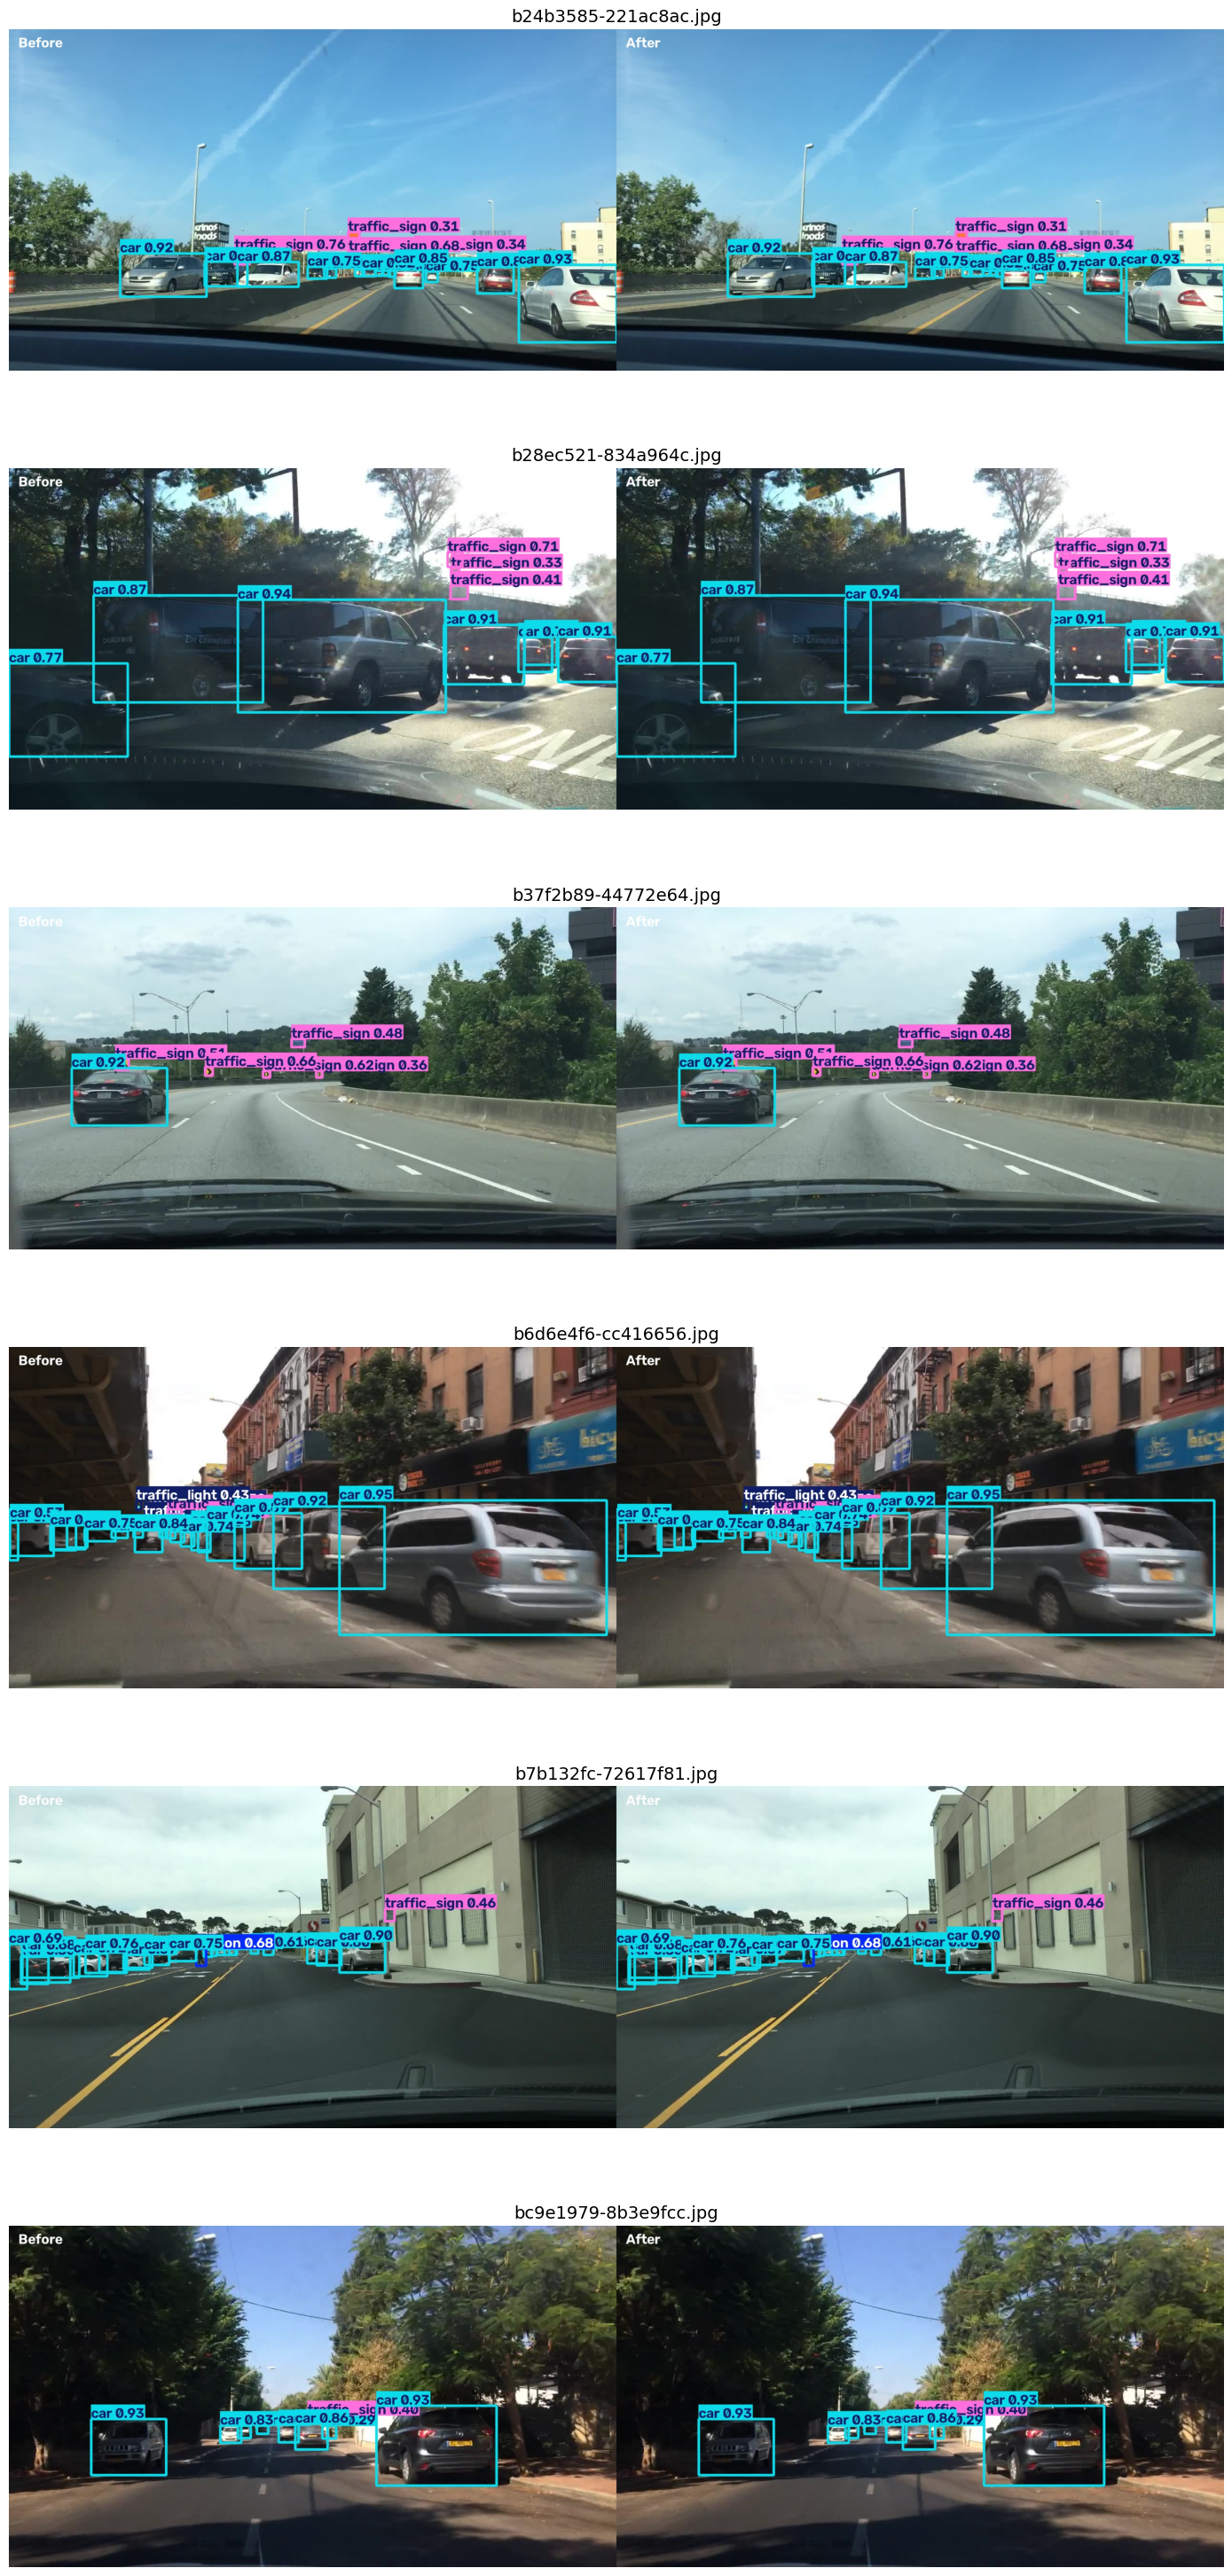

In [116]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

folder = Path("/content/self-healing-detector/results/figures/comparison")
images = sorted(folder.glob("*.jpg")) + sorted(folder.glob("*.png"))

fig, axes = plt.subplots(len(images), 1, figsize=(14, 5*len(images)))
if len(images) == 1:
    axes = [axes]

for ax, img_path in zip(axes, images):
    ax.imshow(Image.open(img_path))
    ax.set_title(img_path.name, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()

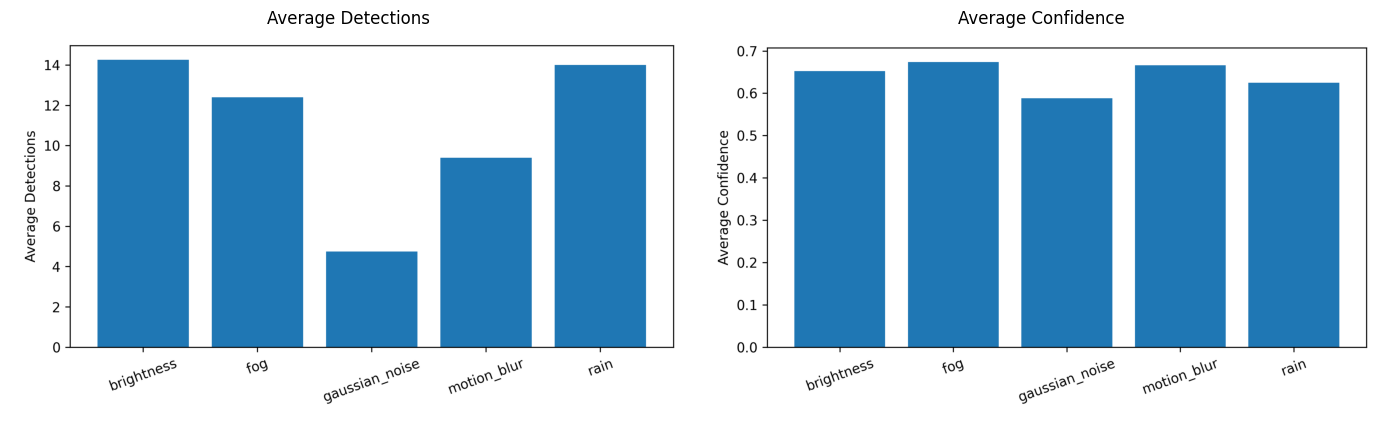

In [117]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(Image.open("/content/self-healing-detector/results/figures/corruption_detections.png"))
axes[0].set_title("Average Detections")
axes[0].axis("off")

axes[1].imshow(Image.open("/content/self-healing-detector/results/figures/corruption_confidence.png"))
axes[1].set_title("Average Confidence")
axes[1].axis("off")

plt.tight_layout()
plt.show()

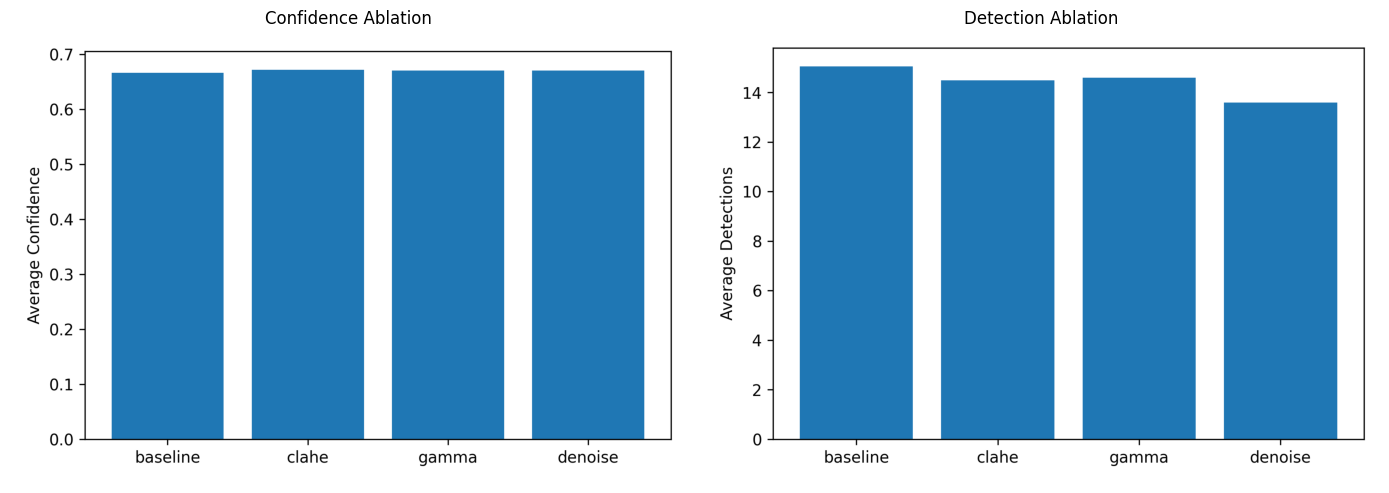

In [118]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(Image.open("/content/self-healing-detector/results/figures/ablation_conf.png"))
axes[0].set_title("Confidence Ablation")
axes[0].axis("off")

axes[1].imshow(Image.open("/content/self-healing-detector/results/figures/ablation_det.png"))
axes[1].set_title("Detection Ablation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

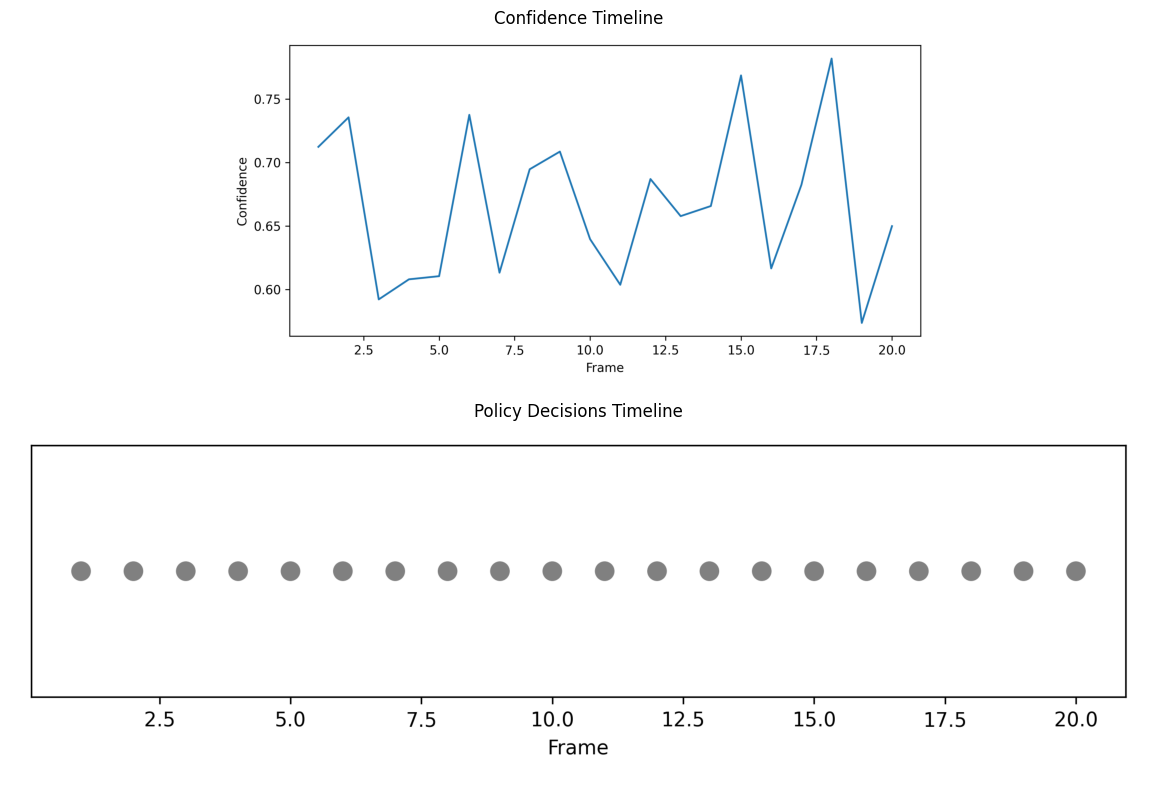

In [119]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].imshow(Image.open("/content/self-healing-detector/results/figures/confidence_timeline.png"))
axes[0].set_title("Confidence Timeline")
axes[0].axis("off")

axes[1].imshow(Image.open("/content/self-healing-detector/results/figures/policy_timeline.png"))
axes[1].set_title("Policy Decisions Timeline")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [120]:
import pandas as pd

df = pd.read_csv("/content/self-healing-detector/results/eval/corruption_summary.csv")
display(df)

,corruption,avg_conf,avg_det
0,brightness,0.652516,14.25
1,fog,0.673406,12.40
2,gaussian_noise,0.588423,4.75
3,motion_blur,0.666193,9.40
4,rain,0.624677,14.00


In [121]:
import pandas as pd

df = pd.read_csv("/content/self-healing-detector/results/ablation/ablation.csv")
display(df)

,method,images,avg_conf,avg_det,conf_delta,det_delta
0,baseline,20,0.666929,15.05,0.000000,0.00
1,clahe,20,0.671959,14.50,0.005029,-0.55
2,gamma,20,0.670657,14.60,0.003728,-0.45
3,denoise,20,0.670506,13.60,0.003576,-1.45


In [122]:
import json
from pprint import pprint

with open("/content/self-healing-detector/results/eval/metrics_summary.json") as f:
    pprint(json.load(f))

{'adaptation_rate': 0.0,
 'avg_confidence': 0.6669294089078903,
 'avg_detections_per_frame': 15.05,
 'frames': 20,
 'max_confidence': 0.9591699838638306,
 'policy_actions': {'none': 20},
 'total_detections': 301}


In [123]:
import pandas as pd

benchmark = pd.DataFrame({
    "Backend": ["PyTorch", "OpenVINO"],
    "Inference Time (ms)": [387.33, 413.61]
})

benchmark["Speedup vs PyTorch"] = [1.00, 0.94]
display(benchmark)

,Backend,Inference Time (ms),Speedup vs PyTorch
0,PyTorch,387.33,1.00
1,OpenVINO,413.61,0.94


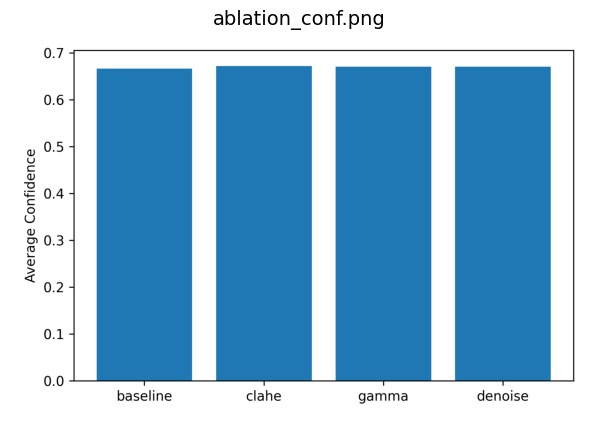

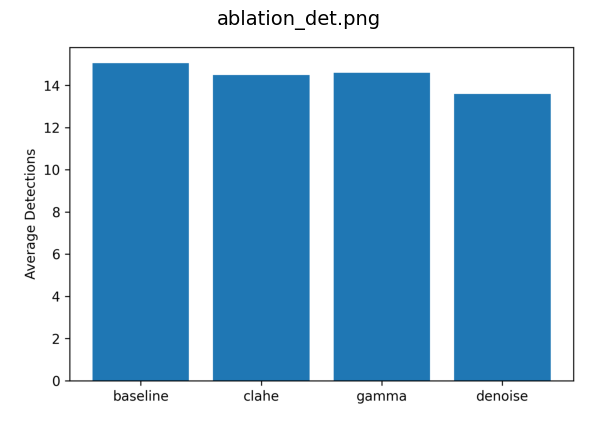

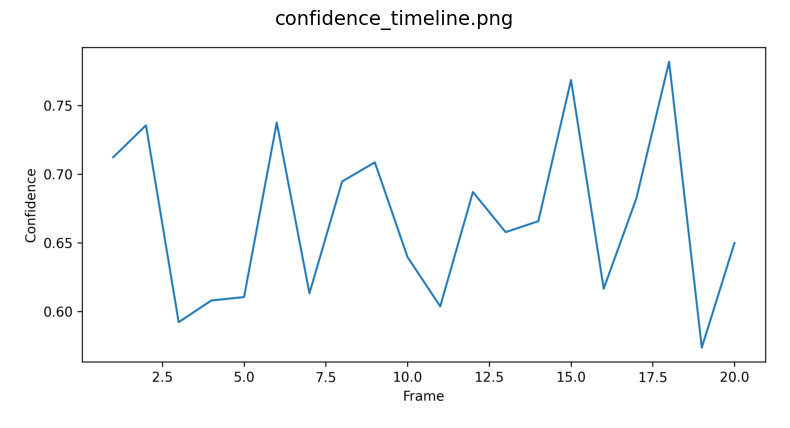

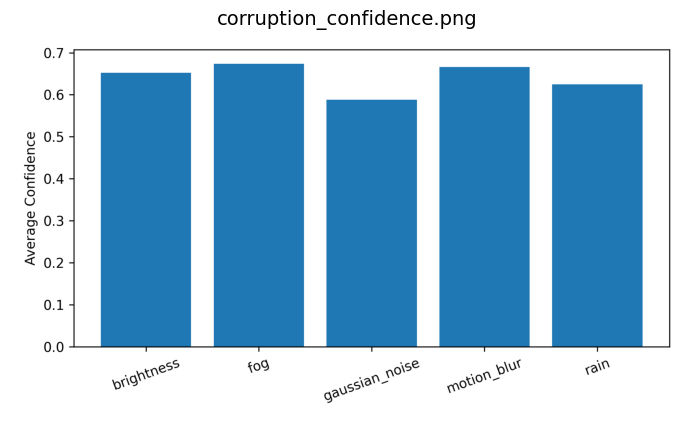

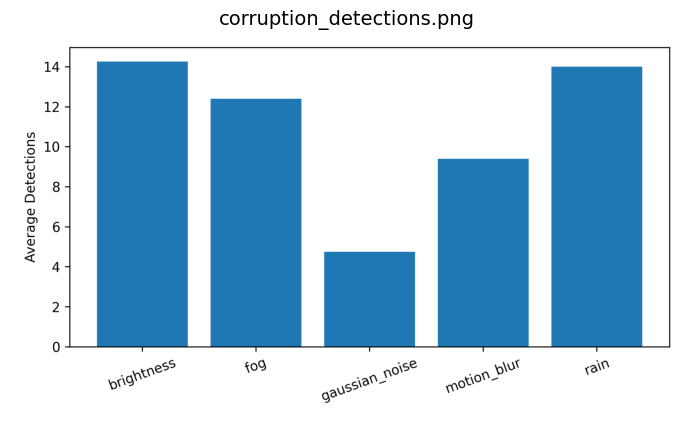

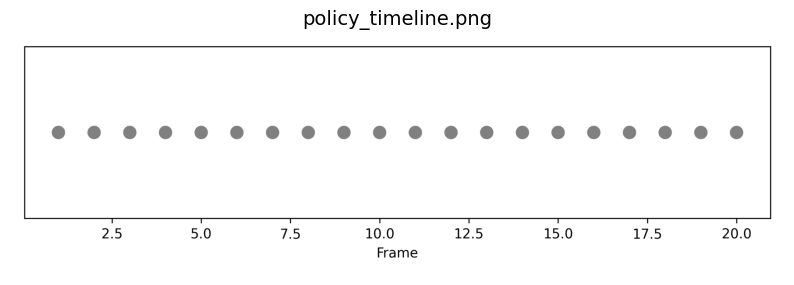

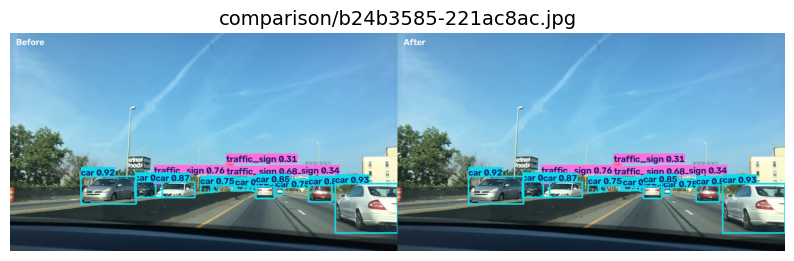

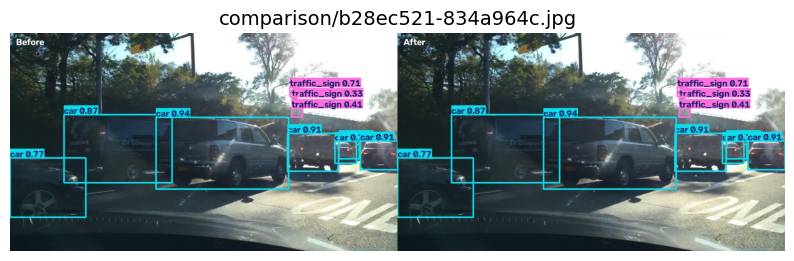

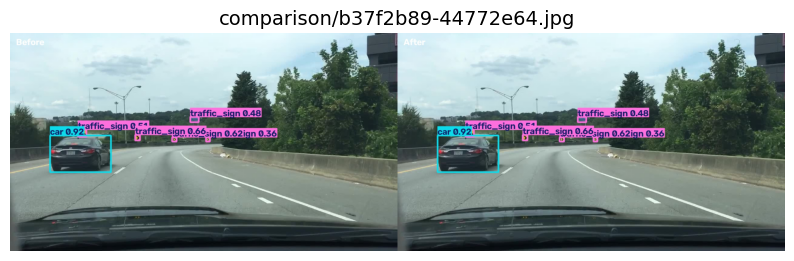

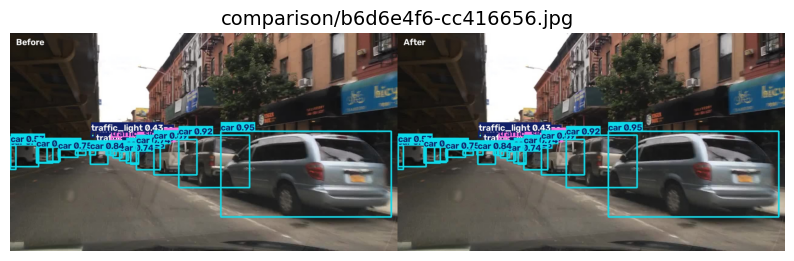

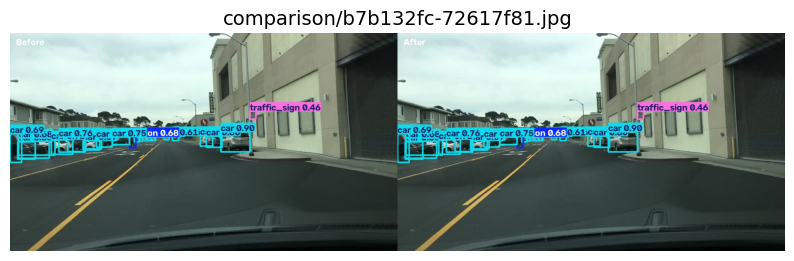

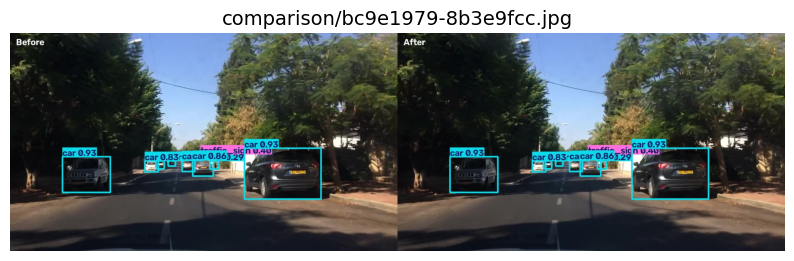

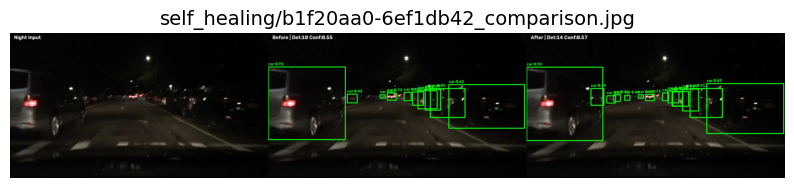

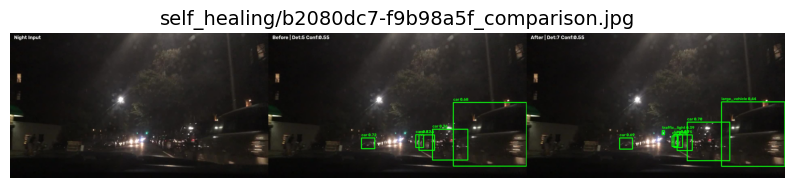

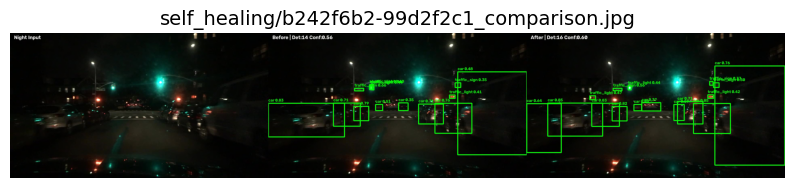

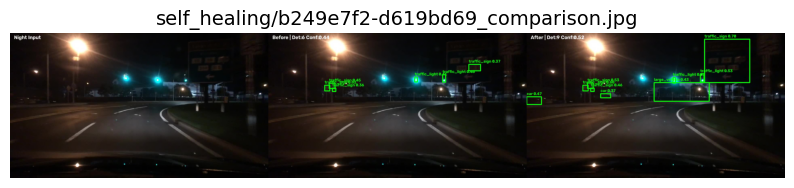

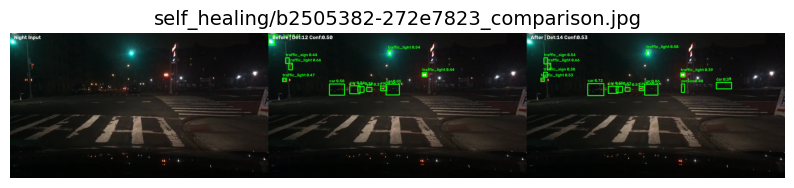

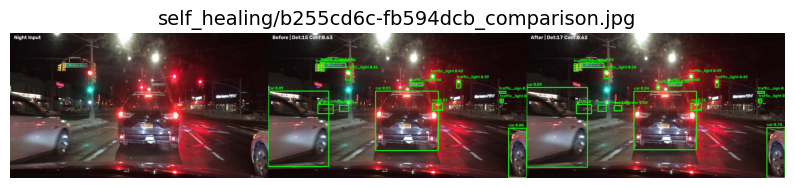

In [124]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

folder = Path("/content/self-healing-detector/results/figures")
images = sorted(folder.rglob("*.png")) + sorted(folder.rglob("*.jpg"))

for img_path in images:
    plt.figure(figsize=(10,5))
    plt.imshow(Image.open(img_path))
    plt.title(img_path.relative_to(folder), fontsize=14)
    plt.axis("off")
    plt.show()

In [125]:
%%writefile /content/self-healing-detector/src/eval/make_self_healing_comparison.py
#!/usr/bin/env python3

import sys
import heapq
from pathlib import Path

REPO_ROOT = Path(__file__).resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import cv2
import pandas as pd

from src.model.infer import Detector
from src.adapt.bn_reest import BNReEstimator

ROOT = REPO_ROOT
OUT = ROOT / "results" / "figures" / "self_healing"
OUT.mkdir(parents=True, exist_ok=True)

SEARCH_IMAGES = 100
BUFFER_IMAGES = 20
TOP_K = 6
CONF_THRESH = 0.35


def draw_boxes(img, dets, names):
    img = img.copy()

    for d in dets.cpu().numpy():
        x1, y1, x2, y2, conf, cls = d[:6]
        cls = int(cls)

        cv2.rectangle(
            img,
            (int(x1), int(y1)),
            (int(x2), int(y2)),
            (0, 255, 0),
            3,
        )

        label = f"{names[cls]} {conf:.2f}"

        cv2.putText(
            img,
            label,
            (int(x1), max(25, int(y1)-8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (0,255,0),
            2,
        )

    return img


night_dir = ROOT / "data" / "yolo" / "val_night" / "images"
night_images = sorted(night_dir.glob("*.jpg"))

print(f"Night images available: {len(night_images)}")
print(f"Searching first {SEARCH_IMAGES} images")

baseline = Detector("weights/best.pt")

adapter = BNReEstimator("weights/best.pt")
print("Running BN Re-estimation...")
adapter.adapt(night_images, max_images=BUFFER_IMAGES)
adapted = adapter.detector
print("Adaptation complete.")

names = baseline.net.names

best_heap = []
all_rows = []

print("Searching for strongest recovery examples...")

for i, p in enumerate(night_images[:SEARCH_IMAGES]):

    img = cv2.imread(str(p))
    if img is None:
        continue

    before = baseline.apply_deploy_thresholds(
        baseline.infer(img, conf=CONF_THRESH)["detections"]
    )

    after = adapted.apply_deploy_thresholds(
        adapted.infer(img, conf=CONF_THRESH)["detections"]
    )

    b_det = len(before)
    a_det = len(after)

    b_conf = float(before[:,4].mean().cpu()) if b_det else 0.0
    a_conf = float(after[:,4].mean().cpu()) if a_det else 0.0

    det_gain = a_det - b_det
    conf_gain = a_conf - b_conf

    # Keep only meaningful recoveries
    if det_gain <= 0:
        continue

    # Reject cases where confidence drops noticeably
    if a_conf < b_conf - 0.03:
        continue

    score = det_gain + conf_gain

    all_rows.append({
        "image": p.name,
        "before_det": b_det,
        "after_det": a_det,
        "before_conf": b_conf,
        "after_conf": a_conf,
        "det_gain": det_gain,
        "conf_gain": conf_gain,
        "score": score,
    })

    item = (
        score,
        str(p),
        b_det,
        a_det,
        b_conf,
        a_conf,
    )

    if len(best_heap) < TOP_K:
        heapq.heappush(best_heap, item)
    else:
        heapq.heappushpop(best_heap, item)

    if (i+1) % 25 == 0:
        print(f"{i+1}/{SEARCH_IMAGES}")

best = sorted(best_heap, reverse=True)

rows = []

print("\nGenerating figures...")

for score, path, b_det, a_det, b_conf, a_conf in best:

    p = Path(path)
    img = cv2.imread(str(p))

    before = baseline.apply_deploy_thresholds(
        baseline.infer(img, conf=CONF_THRESH)["detections"]
    )

    after = adapted.apply_deploy_thresholds(
        adapted.infer(img, conf=CONF_THRESH)["detections"]
    )

    raw = img.copy()
    before_img = draw_boxes(img, before, names)
    after_img = draw_boxes(img, after, names)

    panel = cv2.hconcat([raw, before_img, after_img])

    w = panel.shape[1] // 3

    cv2.putText(panel, "Night Input",
                (20,35),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.85,
                (255,255,255),
                2)

    cv2.putText(panel,
                f"Before | Det:{b_det} Conf:{b_conf:.2f}",
                (w+20,35),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.85,
                (255,255,255),
                2)

    cv2.putText(panel,
                f"After | Det:{a_det} Conf:{a_conf:.2f}",
                (2*w+20,35),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.85,
                (255,255,255),
                2)

    cv2.imwrite(str(OUT/f"{p.stem}_comparison.jpg"), panel)

    rows.append({
        "image": p.name,
        "before_det": b_det,
        "after_det": a_det,
        "before_conf": b_conf,
        "after_conf": a_conf,
        "score": score,
    })

pd.DataFrame(rows).sort_values("score", ascending=False).to_csv(
    OUT/"top_self_healing_examples.csv",
    index=False,
)

all_df = pd.DataFrame(all_rows)

summary = pd.DataFrame([{
    "Metric": "Average",
    "Before Detections": all_df.before_det.mean(),
    "After Detections": all_df.after_det.mean(),
    "Detection Gain": all_df.det_gain.mean(),
    "Before Confidence": all_df.before_conf.mean(),
    "After Confidence": all_df.after_conf.mean(),
    "Confidence Gain": all_df.conf_gain.mean(),
}])

summary.to_csv(OUT/"before_after_summary.csv", index=False)

print("\nDone.")
print(f"Saved {len(rows)} comparison figures.")
print(f"Results: {OUT}")

Overwriting /content/self-healing-detector/src/eval/make_self_healing_comparison.py


In [126]:
%cd /content/self-healing-detector
!python src/eval/make_self_healing_comparison.py

/content/self-healing-detector
Night images available: 3929
Searching first 100 images
Running BN Re-estimation...
Adaptation complete.
Searching for strongest recovery examples...
25/100

Generating figures...

Done.
Saved 6 comparison figures.
Results: /content/self-healing-detector/results/figures/self_healing


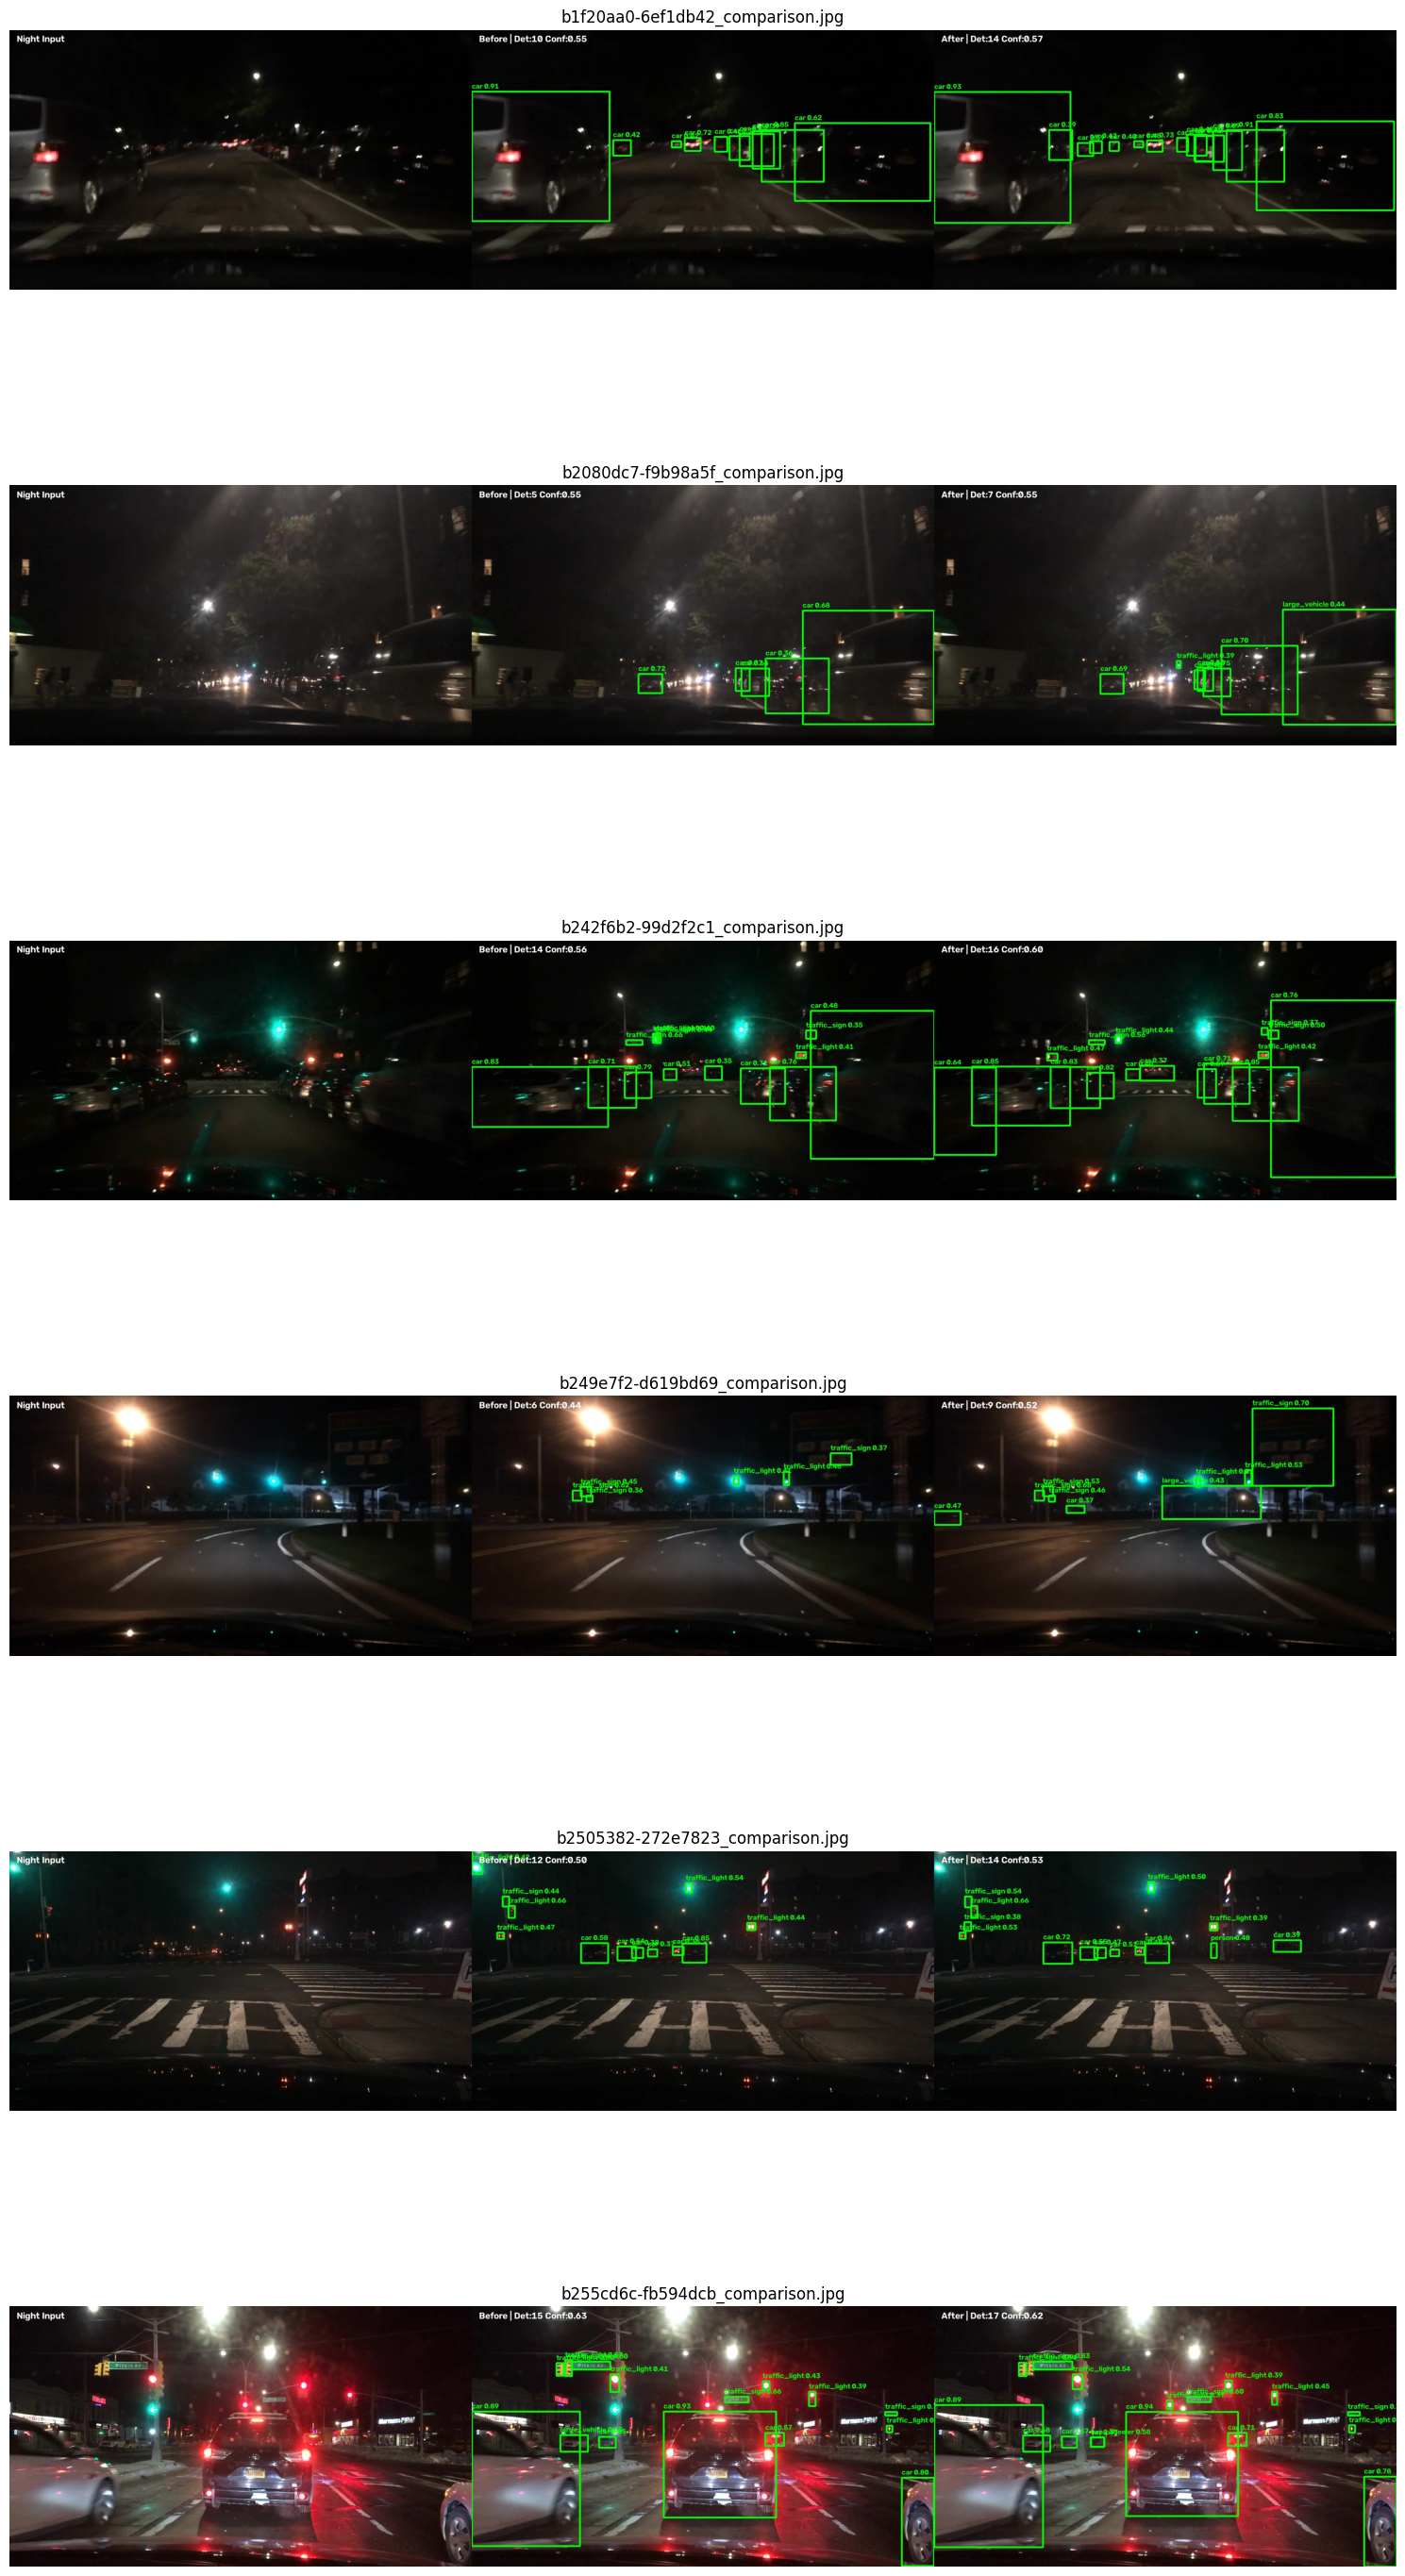

In [127]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

folder=Path("/content/self-healing-detector/results/figures/self_healing")
imgs=sorted(folder.glob("*.jpg"))

fig,axes=plt.subplots(len(imgs),1,figsize=(15,5*len(imgs)))

if len(imgs)==1:
    axes=[axes]

for ax,p in zip(axes,imgs):
    ax.imshow(Image.open(p))
    ax.set_title(p.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [93]:
from ultralytics import YOLO

model = YOLO("/content/self-healing-detector/weights/best.pt")

print("Number of classes:", len(model.names))
print(model.names)

Number of classes: 6
{0: 'person', 1: 'car', 2: 'large_vehicle', 3: 'two_wheeler', 4: 'traffic_light', 5: 'traffic_sign'}


In [94]:
# ===== Package Self-Healing Detector =====

import shutil
from pathlib import Path
from google.colab import files

ROOT = Path("/content/self-healing-detector")
ASSETS = ROOT / "assets"

# Clean assets folder
if ASSETS.exists():
    shutil.rmtree(ASSETS)

ASSETS.mkdir(parents=True)

print("Collecting generated assets...")

# Copy all generated figures, metrics and reports
extensions = [
    "*.png","*.jpg","*.jpeg","*.svg","*.pdf",
    "*.csv","*.json","*.txt"
]

folders_to_collect = [
    ROOT/"results",
]

for folder in folders_to_collect:
    if folder.exists():
        for ext in extensions:
            for f in folder.rglob(ext):
                rel = f.relative_to(ROOT/"results")
                dst = ASSETS/"results"/rel
                dst.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(f, dst)

# Copy configs
if (ROOT/"configs").exists():
    shutil.copytree(ROOT/"configs", ASSETS/"configs", dirs_exist_ok=True)

# Copy important logs if they exist
for f in [
    ROOT/"weights/bn_source_stats.pt",
]:
    if f.exists():
        dst = ASSETS/"weights"/f.name
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(f, dst)

print("Creating ZIP files...")

# Create full repository zip
shutil.make_archive(
    "/content/self-healing-detector",
    "zip",
    ROOT.parent,
    ROOT.name
)

# Create src-only zip
shutil.make_archive(
    "/content/src_only",
    "zip",
    ROOT/"src"
)

print("\nDone!")
print("Files created:")
print(" - /content/self-healing-detector.zip")
print(" - /content/src_only.zip")

# Download automatically
files.download("/content/self-healing-detector.zip")
files.download("/content/src_only.zip")

Creating ZIP files...

Done!
Files created:
 - /content/self-healing-detector.zip
 - /content/src_only.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>